<a href="https://colab.research.google.com/github/freitas-oa/Computer-Vision/blob/main/Food_acceptance_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Food Acceptance Project**

**Authors:** Adriany Oliveira, Luís Vieira  
**Date:** 18/12/2025


##1. Business Understanding

**Note:** *This section was refined following the Data Understanding phase to reflect the significant class imbalance observed in the target variable (94% Success vs. 6% Failure). The objectives and success criteria have been adjusted to prioritize failure detection over general accuracy.*

### 1.1 Business Problem

Food companies rely heavily on sensory panels to predict market performance. However, these tests are expensive, time-consuming, and subjective. Furthermore, the market reality is highly skewed: the vast majority of developed products are commercially viable, making the rare commercial failures (approx. 6%) both unexpected and financially damaging.

The dataset simulates real corporate product data, including:

- Product Characteristics: Ingredients and technical specifications.

- Sensory Scores: Ratings from human taste testers.

- Market Variables: External factors influencing sales.

- Target Labels: `overall_appreciation` (numeric score) and `success` (binary commercial outcome).

**The Core Challenge**: The primary business risk is not missing a successful product (since success is the norm), but failing to detect a disastrous one. Launching a product that commercially flops results in wasted manufacturing resources, marketing spend, and potential brand damage. Consequently, the central question is: Can Machine Learning effectively mitigate this risk by acting as a pre-launch screening mechanism to identify and filter out non-viable products before they reach the market?

### 1.2 Business Objectives

- **Detect "Failures" (Class 0) Pre-Launch**: Shift the primary modeling focus from predicting success to identifying the minority of high-risk products that are likely to fail.

- **Investigate Data Balancing Strategies**: Assess whether training on balanced data (amplifying the signal of rare failures) effectively improves the detection of high-risk products compared to standard approaches, or if it introduces unacceptable false alarms.

- **Reduce Reliance on Sensory Panels**: Determine if technical or marketing features alone can provide a sufficient signal to screen out poor products, potentially reducing the need for expensive human testing in early development stages.

- **Optimize for Asymmetric Costs**: Build a decision framework that prioritizes Recall (catching all failures) over Precision (avoiding false alarms), acknowledging that double-checking a flagged product is significantly cheaper than launching a failed one.

### 1.3 Success Criteria

**Business Success**:

A deployed model that reliably flags a significant portion (e.g., >80%) of potential market failures before launch, allowing the business to intervene or cancel the project.

**Machine Learning Success (Classification)**:
- *Metric Strategy*: Given the 94% success rate, accuracy is a misleading metric. Evaluation will strictly prioritize penalizing missed failures over false alarms.


- *Primary Metrics*: Performance will be assessed via Recall (Sensitivity) and F1-Score for Class 0. The objective is to maximize failure detection without degrading precision to operationally unusable levels.


- *Comparative Hypothesis*: We aim to empirically determine if training on SMOTE-balanced distributions yields a quantifiable improvement in minority class detection compared to the raw, imbalanced baseline when evaluated on real-world data.

- *Stability*: The model must demonstrate a PR-AUC that significantly exceeds the baseline, confirming it is distinguishing signal from noise rather than exploiting probability thresholds.

**Machine Learning Overall_appreciation (Regression)**:

Goal: Accurately forecast the overall_appreciation score.

**Metrics**: We target low MAE (Mean Absolute Error) and RMSE, with an R² score indicating the model captures a significant portion of the variance in human preference. Consistency between validation and test sets is required to ensure generalization.


## 2. Data Understanding

### 2.1 First Look at the Data
In this step, we load the dataset and get a general sense of what we are working with.  
The goal is simply to understand the structure: number of rows, columns, data types, and whether any variables look incomplete or inconsistent.

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel("food_product_acceptance_dataset.xlsx")

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   product_id                   2000 non-null   object 
 1   name                         2000 non-null   object 
 2   category                     2000 non-null   object 
 3   subcategory                  2000 non-null   object 
 4   description                  2000 non-null   object 
 5   country_origin               2000 non-null   object 
 6   calories                     2000 non-null   int64  
 7   fat_g                        2000 non-null   float64
 8   sugar_g                      2000 non-null   float64
 9   protein_g                    1929 non-null   float64
 10  fiber_g                      1937 non-null   float64
 11  sodium_mg                    2000 non-null   int64  
 12  organic                      2000 non-null   bool   
 13  gluten_free       

In [3]:
df.isna().sum().sort_values(ascending=False).head(10)

,0
protein_g,71
aroma_intensity,70
umami,65
fiber_g,63
name,0
subcategory,0
country_origin,0
category,0
description,0
product_id,0


In [4]:
df.duplicated().sum()

np.int64(0)

The dataset loads correctly and shows a clean structure: all columns have consistent data types, and the descriptive statistics suggest reasonable numeric ranges. Missing values appear mainly in protein_g, aroma_intensity, umami, and fiber_g, which will require imputation later. No duplicated rows were found, indicating good data integrity.

### 2.2 Descriptive Analysis

In this step, we look at the basic statistical behavior of our features.  
This helps us understand typical values, detect outliers, and get an early sense of how sensory and external variables differ.  
We use summary statistics, histograms, and boxplots to build this first overview.


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
calories,2000.0,202.360000,98.161006,9.000000,130.750000,187.0000,261.000000,520.00
fat_g,2000.0,6.845400,3.561401,0.200000,3.875000,6.9000,9.300000,16.90
sugar_g,2000.0,9.761500,3.754188,0.500000,6.800000,9.7000,12.300000,24.00
protein_g,1929.0,9.354743,5.429603,0.400000,5.600000,7.3000,13.200000,25.90
fiber_g,1937.0,2.378782,1.683788,0.100000,0.900000,2.2000,3.400000,8.00
sodium_mg,2000.0,220.665500,259.859069,8.000000,101.000000,165.0000,277.000000,5520.00
spicy_level,2000.0,1.496500,1.278204,0.000000,0.000000,1.0000,2.000000,5.00
color_intensity,2000.0,4.812650,2.086234,0.000000,3.300000,4.8000,6.200000,10.00
aroma_intensity,1930.0,5.478860,1.961022,0.000000,4.200000,5.5000,6.800000,10.00
sweetness,2000.0,4.609800,2.681261,0.000000,2.500000,4.5000,6.700000,10.00


In [6]:
df.select_dtypes(include=["object", "bool"]).nunique().sort_values(ascending=False)


,0
product_id,1999
description,1955
name,925
subcategory,39
country_origin,20
category,9
organic,2
gluten_free,2
contains_nuts,2
contains_meat,2


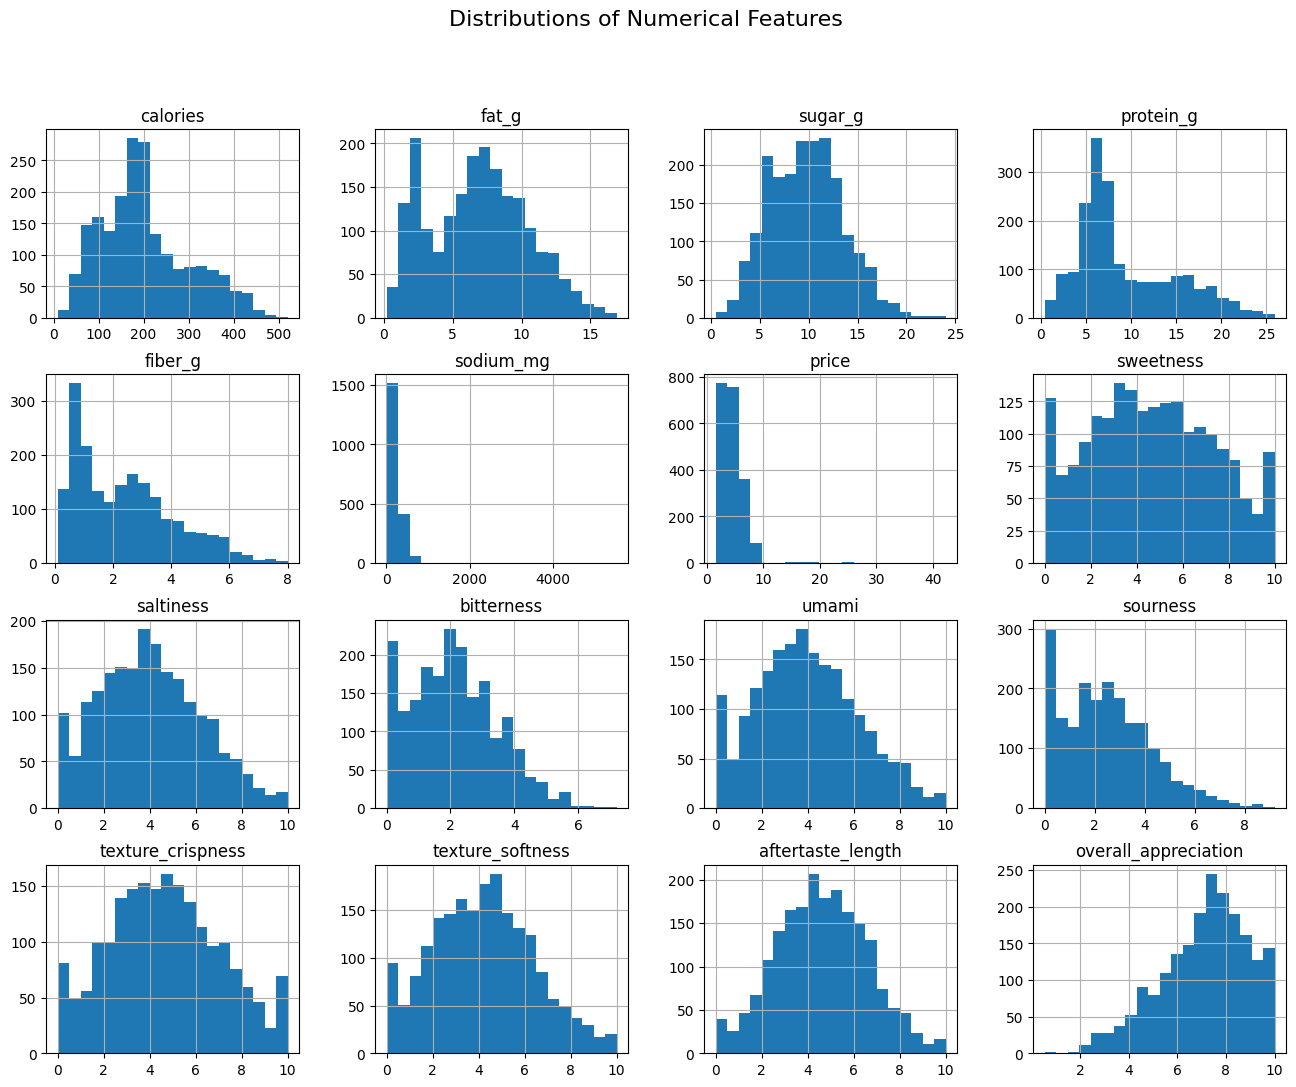

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['calories', 'fat_g', 'sugar_g', 'protein_g',
                'fiber_g', 'sodium_mg', 'price',
                'sweetness', 'saltiness', 'bitterness',
                'umami', 'sourness', 'texture_crispness',
                'texture_softness', 'aftertaste_length',
                'overall_appreciation']

df[numerical_cols].hist(figsize=(16, 12), bins=20)
plt.suptitle("Distributions of Numerical Features", fontsize=16)
plt.show()


The histograms and boxplots together show a clear picture of how the numerical features behave. Most nutritional variables (calories, fat, sugar, protein, fiber) are **right-skewed**, meaning most products have moderate values while a smaller group shows much higher amounts. Sensory attributes follow smoother, mostly unimodal distributions, with bitterness and sourness rated lower on average. Texture-related variables also display stable mid-range patterns.

The boxplots confirm these observations and reveal **strong outliers** in a few variables, especially **sodium_mg** and **price**, which contain extreme high values far from the rest of the data. These long right tails may affect scaling and some models later. Sensory features and the target **overall_appreciation** show compact, well-behaved distributions with no major outliers, which makes them more predictable for machine learning.

Overall, sensory variables behave consistently and are likely reliable predictors, while some nutritional and price features will require careful treatment due to skewness and outliers.


#### 2.2.2 Outliers

Top 10 columns selected: ['sodium_mg', 'price', 'sourness', 'fiber_g', 'calories', 'protein_g', 'sugar_g', 'bitterness', 'fat_g', 'saltiness']


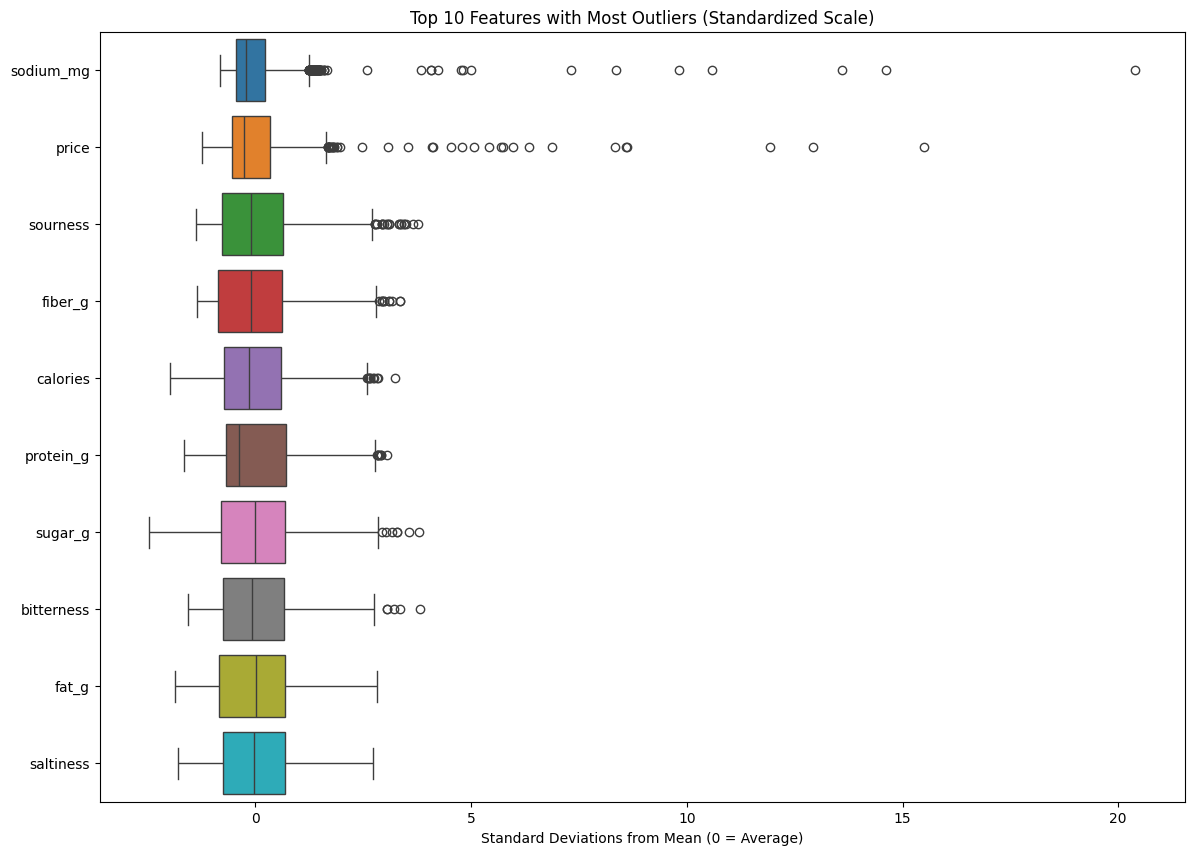

In [8]:
from sklearn.preprocessing import StandardScaler

# 1. Define columns to exclude from analysis
exclude_cols = ['overall_appreciation', 'success']
features_to_analyze = [col for col in numerical_cols if col not in exclude_cols]

# 2. Calculate Outlier Counts using IQR method (on filtered features)
Q1 = df[features_to_analyze].quantile(0.25)
Q3 = df[features_to_analyze].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_mask = (df[features_to_analyze] < lower_bound) | (df[features_to_analyze] > upper_bound)
outliers_count = outliers_mask.sum()

# 3. Get top 10 columns with most outliers (excluding the ignored ones)
sorted_cols = outliers_count.sort_values(ascending=False).index.tolist()
top_10_cols = sorted_cols[:10]

print("Top 10 columns selected:", top_10_cols)

# 4. Create a temporary scaled DataFrame for visualization
scaler = StandardScaler()
df_scaled_vis = pd.DataFrame(scaler.fit_transform(df[top_10_cols]), columns=top_10_cols)

# 5. Plot the Scaled Data
plt.figure(figsize=(14, 10))
sns.boxplot(data=df_scaled_vis, orient="h")
plt.title("Top 10 Features with Most Outliers (Standardized Scale)")
plt.xlabel("Standard Deviations from Mean (0 = Average)")
plt.show()

The analysis shows that sodium_mg and price have the most extreme outliers, reaching values very far from the average. While review_count_prelaunch has the largest quantity of outliers, they are clustered closer to the normal range. Most features only show high-value outliers, but marketing_spend_k is unique for having outliers on both the low and high ends.

### 2.3 Target Analysis

In this step we focus on the two targets of the project:
- `overall_appreciation` (regression)
- `success` (classification)

The goal is to understand their distributions and check for class imbalance.

#### 2.3.1 `overall_appreciation `

In [9]:
df["overall_appreciation"].describe()

,overall_appreciation
count,2000.000000
mean,7.092942
std,1.784600
min,0.548065
25%,5.982634
50%,7.320900
75%,8.402952
max,10.000000


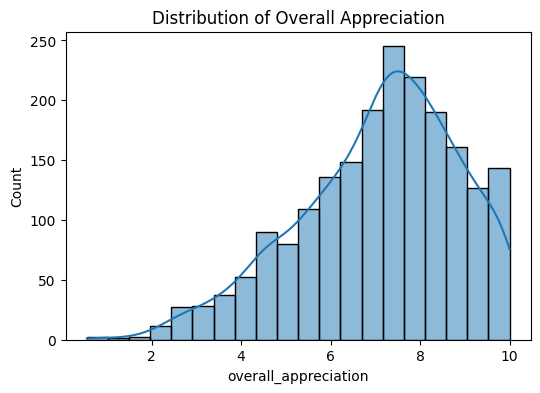

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df["overall_appreciation"], bins=20, kde=True)
plt.title("Distribution of Overall Appreciation")
plt.xlabel("overall_appreciation")
plt.ylabel("Count")
plt.show()


The distribution of overall_appreciation is clearly left-skewed, indicating a strong bias toward positive sensory ratings. The data is heavily concentrated in the 7 to 9 range, with a median score of approximately 7.3. Notably, 75% of products scored above 6.0, while ratings below 4 are rare.

This imbalance means the regression model will be trained primarily on high-scoring products. Consequently, it may achieve high accuracy for popular items but struggle to generalize or accurately predict lower appreciation scores due to the scarcity of negative examples.


#### 2.3.2 `success`

In [11]:
# Absolute and relative frequency of each class
class_counts = df["success"].value_counts()
class_percent = df["success"].value_counts(normalize=True) * 100

class_counts, class_percent

(success
 1    1875
 0     125
 Name: count, dtype: int64,
 success
 1    93.75
 0     6.25
 Name: proportion, dtype: float64)

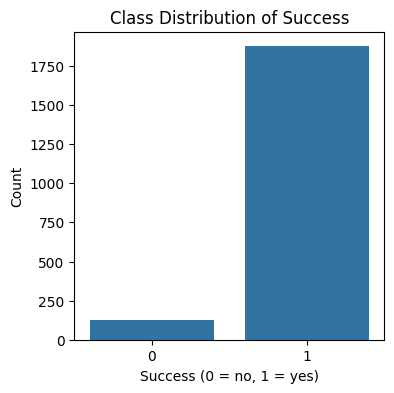

In [12]:
plt.figure(figsize=(4,4))
sns.countplot(x="success", data=df)
plt.title("Class Distribution of Success")
plt.xlabel("Success (0 = no, 1 = yes)")
plt.ylabel("Count")
plt.show()


We observe a severe class imbalance in the success variable. Positive outcomes (Class 1) overwhelmingly dominate the dataset, accounting for 93.75% (1,875 samples), while negative outcomes (Class 0) represent only 6.25% (125 samples).

This disparity presents a significant challenge. A naive model could achieve ~94% accuracy simply by predicting "Success" for every instance, failing to detect any failures. Consequently, we cannot rely on raw accuracy; we must prioritize metrics like Precision, Recall, and F1-Score to properly evaluate performance on the minority class.

To address this imbalance and improve the model's ability to learn the minority class, we will employ SMOTENC (Synthetic Minority Over-sampling Technique for Nominal and Continuous) during the preprocessing stage.


### 2.4 Bivariate Analysis

Here we explore how features relate to each other and to the two targets.  
We begin with correlation matrices, then look at bivariate relationships for numerical variables using simple regression trendlines and analyze categorical variables with Chi-test.


#### 2.4.1 Correlation Matrix

In [13]:
import numpy as np

numeric_df = df.select_dtypes(include=[np.number]).copy()

corr_matrix = numeric_df.corr()
corr_matrix

,calories,fat_g,sugar_g,protein_g,fiber_g,sodium_mg,spicy_level,color_intensity,aroma_intensity,sweetness,...,brand_trust,packaging_appeal,eco_score,shelf_life_days,distribution_channels_count,review_count_prelaunch,allergy_warnings_count,marketing_spend_k,overall_appreciation,success
calories,1.000000,0.751651,-0.307914,0.660662,0.755742,0.506487,0.082713,0.004983,0.028935,-0.044630,...,0.007001,-0.028390,-0.041885,0.025330,-0.005603,0.004587,0.120546,-0.053722,-0.529062,-0.090886
fat_g,0.751651,1.000000,-0.193571,0.423710,0.695243,0.483219,0.080036,0.027038,0.058768,0.065515,...,-0.011361,-0.032071,-0.024808,0.034008,0.015720,0.005979,0.129714,-0.050300,-0.415322,-0.034417
sugar_g,-0.307914,-0.193571,1.000000,-0.439015,-0.357001,-0.260572,-0.077422,0.077860,0.029167,0.261348,...,0.038811,0.029170,0.007250,-0.292221,0.014322,0.002213,0.073977,-0.006604,0.393671,0.102138
protein_g,0.660662,0.423710,-0.439015,1.000000,0.476991,0.417716,0.050003,-0.074641,-0.008386,-0.168127,...,-0.018481,-0.001428,-0.049630,-0.062743,-0.034192,0.021879,0.081105,-0.051049,-0.466634,-0.118078
fiber_g,0.755742,0.695243,-0.357001,0.476991,1.000000,0.483495,0.079969,-0.040751,0.031830,-0.088194,...,0.000935,-0.013345,0.005684,0.361268,0.009116,-0.009740,0.026568,-0.023636,-0.492515,-0.069267
sodium_mg,0.506487,0.483219,-0.260572,0.417716,0.483495,1.000000,0.053734,0.059238,0.000815,-0.065830,...,-0.019269,-0.037447,-0.012017,0.073105,-0.005640,-0.006887,0.043560,-0.026489,-0.423338,-0.079921
spicy_level,0.082713,0.080036,-0.077422,0.050003,0.079969,0.053734,1.000000,-0.000837,-0.009315,-0.020790,...,0.030347,-0.010927,0.018513,0.059951,-0.015120,-0.018378,0.004704,-0.032034,-0.087699,-0.007981
color_intensity,0.004983,0.027038,0.077860,-0.074641,-0.040751,0.059238,-0.000837,1.000000,0.036073,0.049926,...,-0.020968,-0.018108,0.003450,-0.100287,-0.011812,0.012658,0.055783,0.010362,0.023265,-0.030422
aroma_intensity,0.028935,0.058768,0.029167,-0.008386,0.031830,0.000815,-0.009315,0.036073,1.000000,0.029488,...,0.032332,-0.025759,0.001977,0.014203,0.010650,-0.030268,0.000491,0.024751,0.245488,0.078433
sweetness,-0.044630,0.065515,0.261348,-0.168127,-0.088194,-0.065830,-0.020790,0.049926,0.029488,1.000000,...,-0.017226,-0.044119,0.005884,-0.352344,0.012710,0.015497,0.153430,0.013202,0.353900,0.057735


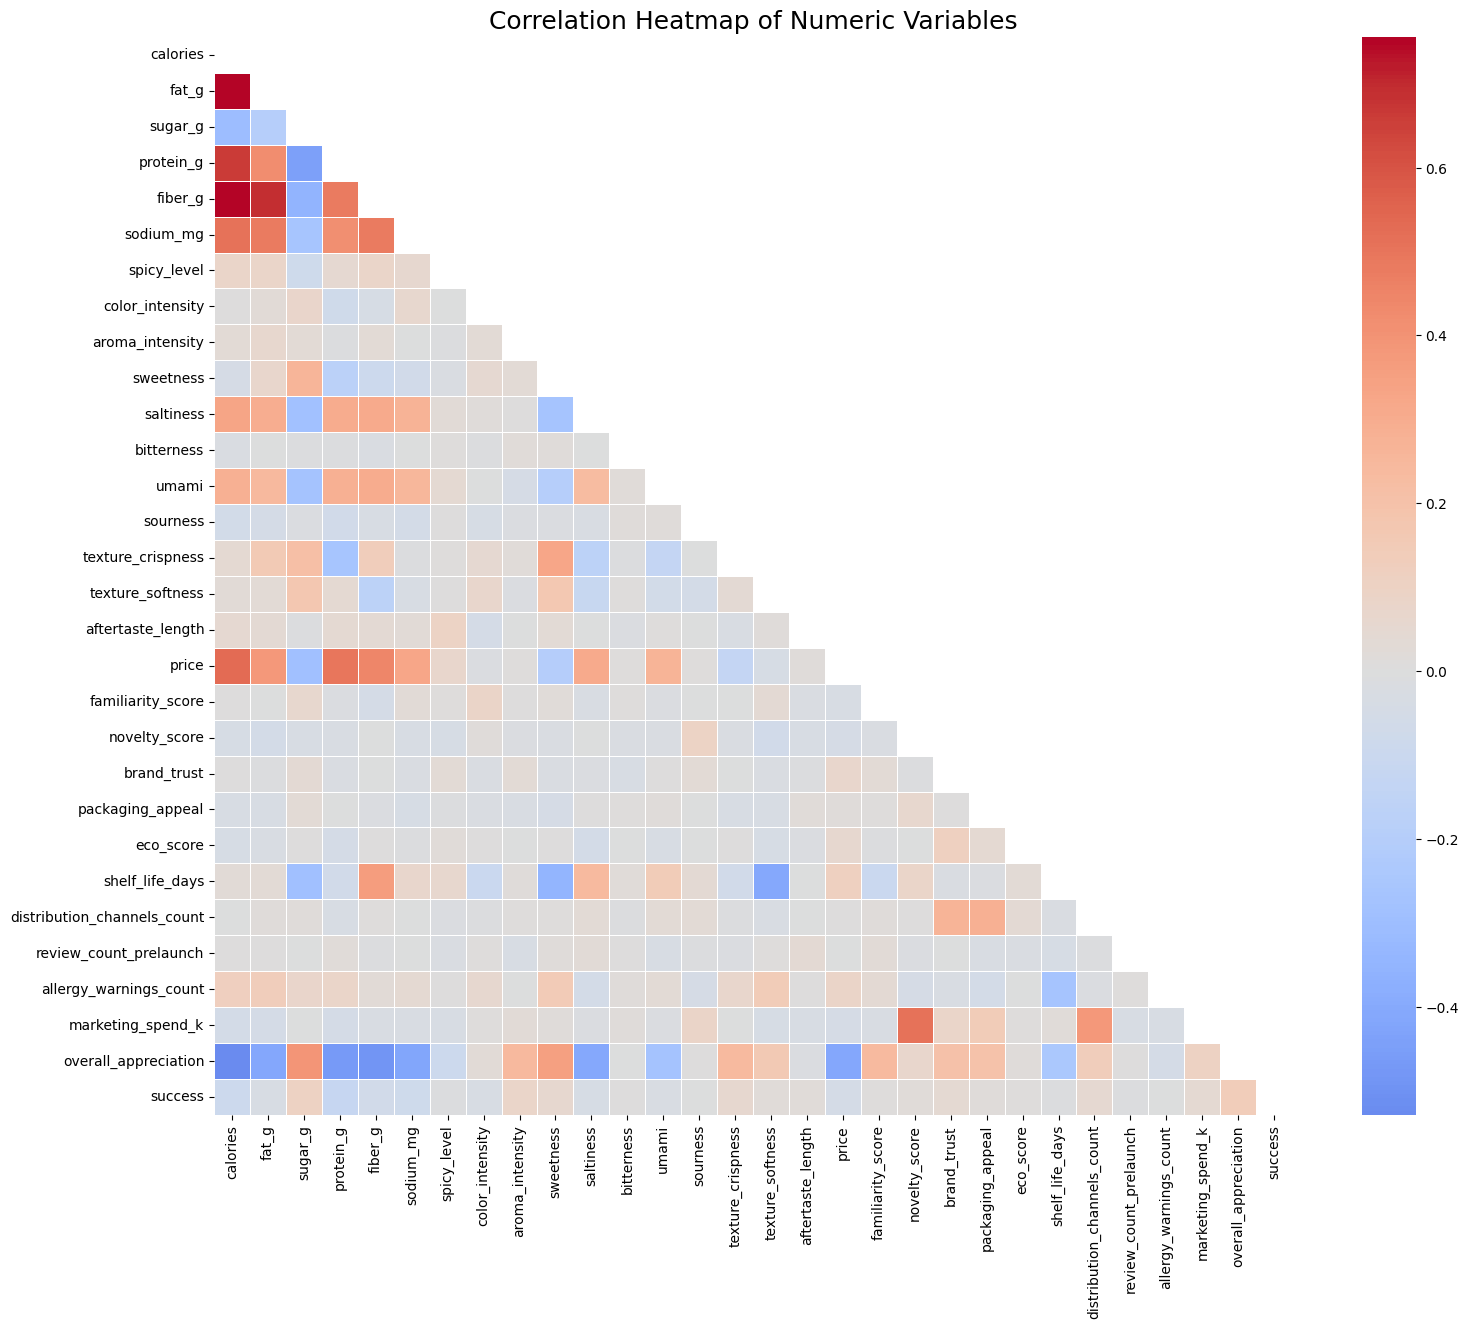

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(18, 14))

# mask upper triangle for readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=False,      # turn to True if you want the numbers
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Numeric Variables", fontsize=18)
plt.show()

All correlations between success and the numeric features are extremely small (|r| < 0.12). Even its correlation with overall_appreciation is only 0.14, which is weak.

This indicates that market success does not have any strong linear relationship with any individual numeric feature. Therefore, linear correlation is not sufficient to understand or predict market success. Non-linear models (tree-based methods, ensembles, neural networks) will likely be required to capture more complex interactions and patterns.


In [15]:
corr_overall = corr_matrix["overall_appreciation"].sort_values(ascending=False)
corr_success = corr_matrix["success"].sort_values(ascending=False)

corr_overall, corr_success

(overall_appreciation           1.000000
 sugar_g                        0.393671
 sweetness                      0.353900
 aroma_intensity                0.245488
 familiarity_score              0.242011
 texture_crispness              0.234477
 brand_trust                    0.198984
 packaging_appeal               0.194647
 texture_softness               0.159948
 success                        0.137208
 distribution_channels_count    0.129046
 marketing_spend_k              0.098867
 novelty_score                  0.069333
 color_intensity                0.023265
 eco_score                      0.016054
 sourness                       0.006250
 review_count_prelaunch         0.004584
 bitterness                    -0.002624
 aftertaste_length             -0.015868
 allergy_warnings_count        -0.050845
 spicy_level                   -0.087699
 shelf_life_days               -0.245475
 umami                         -0.269377
 saltiness                     -0.407257
 fat_g          

/tmp/ipython-input-3597463327.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


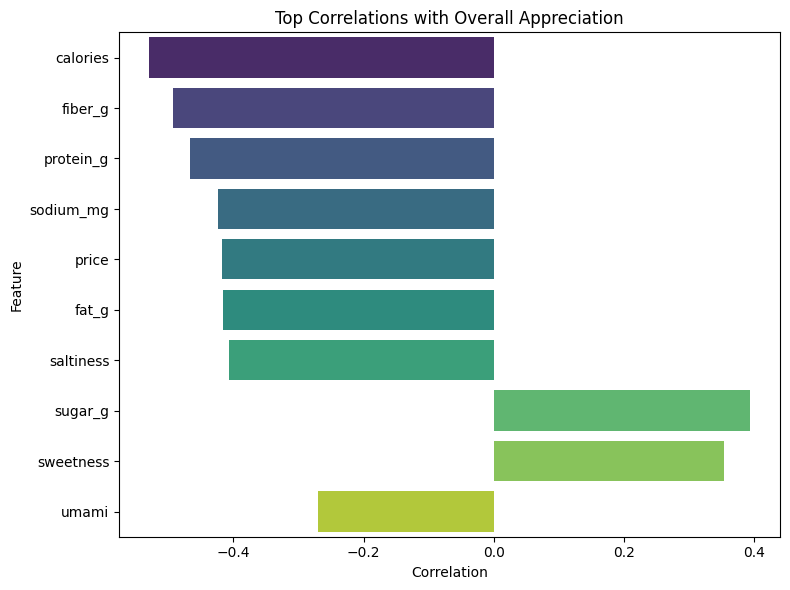

In [16]:

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
corr = df[numerical_cols].corr()

# Strongest correlations with overall_appreciation (excluding itself)
corr_overall = (
    corr["overall_appreciation"]
    .drop("overall_appreciation")
    .sort_values(key=abs, ascending=False)
)

top_n = 10

plt.figure(figsize=(8, 6))
sns.barplot(
    x=corr_overall[:top_n].values,
    y=corr_overall[:top_n].index,
    palette="viridis"
)
plt.title("Top Correlations with Overall Appreciation")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


/tmp/ipython-input-4009314758.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


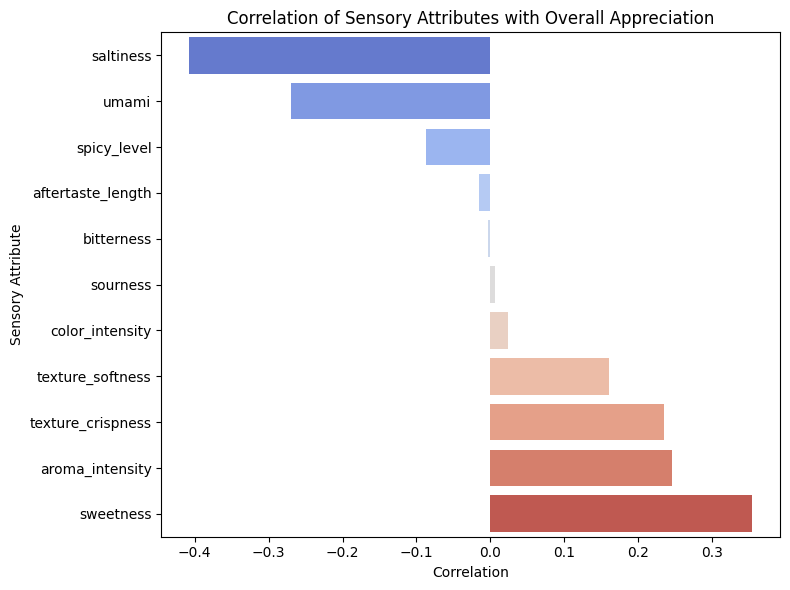

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure success is numeric
df["success"] = df["success"].astype(int)

# List of sensory attributes
sensory_features = [
    'spicy_level',
    'color_intensity',
    'aroma_intensity',
    'sweetness',
    'saltiness',
    'bitterness',
    'umami',
    'sourness',
    'texture_crispness',
    'texture_softness',
    'aftertaste_length'
]

# Compute correlations with overall_appreciation
sensory_corr = df[sensory_features + ["overall_appreciation"]].corr()["overall_appreciation"].drop("overall_appreciation")

# Sort by correlation strength
sensory_corr_sorted = sensory_corr.sort_values(ascending=True)  # lowest to highest

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(
    x=sensory_corr_sorted.values,
    y=sensory_corr_sorted.index,
    palette="coolwarm"
)
plt.title("Correlation of Sensory Attributes with Overall Appreciation")
plt.xlabel("Correlation")
plt.ylabel("Sensory Attribute")
plt.tight_layout()
plt.show()


The bivariate analysis shows that several sensory attributes have a clear positive relationship with `overall_appreciation`. In particular, `sweetness` (0.35), `aroma_intensity` (0.25), `texture_crispness` (0.23), and `texture_softness` (0.16) display upward trends and moderate positive correlations, indicating that products scoring higher on these sensory dimensions tend to receive better appreciation ratings. Other sensory features such as bitterness (-0.00), sourness (0.01), umami (-0.27), spicy_level (-0.09), color_intensity (0.02), and aftertaste_length (-0.02) show little to no linear association.

Nutritional variables reinforce this trend: `sugar_g` (0.39) correlates positively with appreciation, while heavier nutritional components like `calories `(-0.53), `protein_g` (-0.47), `fiber_g` (-0.49), and `sodium_mg` (-0.42) correlate negatively.


#### 2.4.2 Categorical Features vs Success (Chi-Square Test)

To understand whether each categorical variable is statistically associated with the target **success**, we run a Chi-Square independence test. A low p-value (typically < 0.05) indicates that the feature and the target are *not independent*, meaning the category distribution differs between successful and unsuccessful products.


In [18]:
from scipy.stats import chi2_contingency
import pandas as pd

categorical_vars = [
    'category', 'subcategory', 'country_origin',
    'organic', 'gluten_free', 'contains_nuts',
    'contains_meat', 'contains_dairy', 'seasonal'
]

rows = []

for col in categorical_vars:
    table = pd.crosstab(df[col], df['success'])
    chi2, p, dof, expected = chi2_contingency(table)
    rows.append({
        "variable": col,
        "chi2": chi2,
        "p_value": p
    })

chi2_df = (
    pd.DataFrame(rows)
    .sort_values("p_value")
    .assign(significant_0_05=lambda d: d["p_value"] < 0.05)
)

chi2_df


,variable,chi2,p_value,significant_0_05
0,category,41.751044,0.000002,True
1,subcategory,61.234239,0.009840,True
2,country_origin,35.739713,0.011360,True
3,organic,1.550174,0.213110,False
5,contains_nuts,1.331962,0.248456,False
4,gluten_free,0.557093,0.455434,False
8,seasonal,0.504390,0.477577,False
6,contains_meat,0.414083,0.519905,False
7,contains_dairy,0.052136,0.819388,False


The Chi-Square results show that only **category**, **subcategory**, and **country_origin** have significant associations with success (p < 0.05). This means success rates differ across these groups. All other categorical features show high p-values, indicating no meaningful relationship with success in this dataset.


#### 2.4.3 Sucess vs Outliers

--- Failure Rate Analysis (Focus on Class 0) ---
                   Feature  Failure_Rate_Outliers  Failure_Rate_Normal   Lift
11        packaging_appeal                  0.333                0.062  5.368
0                 calories                  0.300                0.061  4.893
15       marketing_spend_k                  0.143                0.062  2.307
4                sodium_mg                  0.128                0.059  2.153
2                protein_g                  0.125                0.062  2.008
10             brand_trust                  0.100                0.062  1.605
3                  fiber_g                  0.091                0.062  1.458
5          aroma_intensity                  0.083                0.062  1.336
13  review_count_prelaunch                  0.045                0.064  0.702
8                    price                  0.027                0.063  0.428
1                  sugar_g                  0.000                0.063  0.000
6              

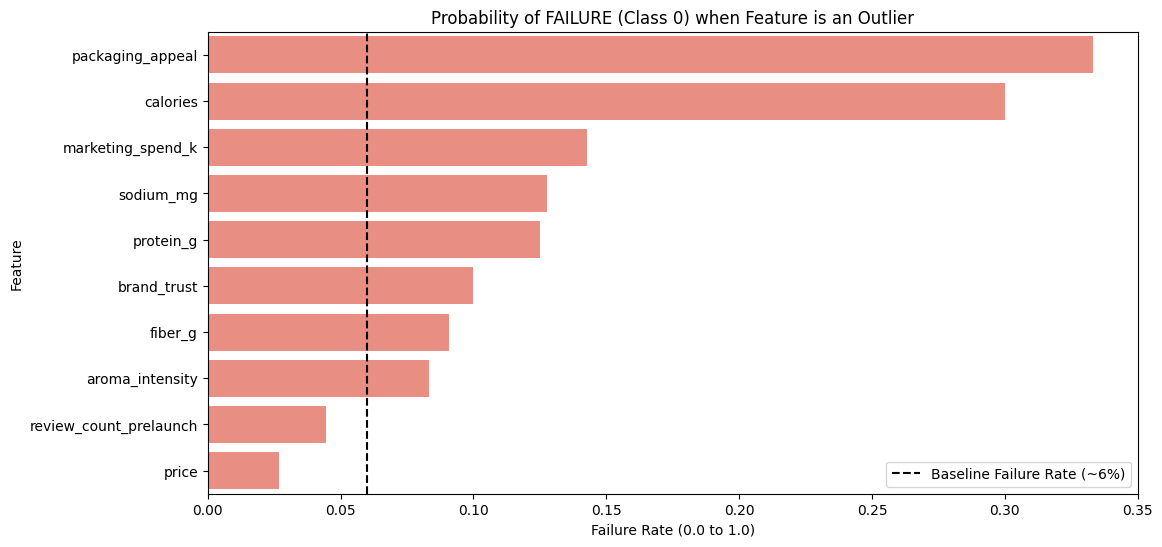

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Re-using the logic to identify outliers and calculating FAILURE rate (Class 0)
# Failure Rate = 1 - Success Rate

exclude_cols = ['overall_appreciation', 'success']
features_to_analyze = [col for col in numerical_cols if col not in exclude_cols]

Q1 = df[features_to_analyze].quantile(0.25)
Q3 = df[features_to_analyze].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

results_failure = []

for col in features_to_analyze:
    is_outlier = (df[col] < lower_bound[col]) | (df[col] > upper_bound[col])

    # Calculate FAILURE rate (Target == 0)
    # Using 1 - mean() of success gives us the failure percentage
    fail_rate_outlier = 1 - df.loc[is_outlier, 'success'].mean()
    fail_rate_normal = 1 - df.loc[~is_outlier, 'success'].mean()

    # Only keep features where outliers exist
    if is_outlier.sum() > 0:
        results_failure.append({
            'Feature': col,
            'Outlier_Count': is_outlier.sum(),
            'Failure_Rate_Outliers': fail_rate_outlier,
            'Failure_Rate_Normal': fail_rate_normal,
            'Lift': fail_rate_outlier / fail_rate_normal if fail_rate_normal > 0 else 0
        })

# Sort by Lift (How many times more likely to fail are the outliers?)
df_fail_analysis = pd.DataFrame(results_failure).sort_values(by='Failure_Rate_Outliers', ascending=False)

print("--- Failure Rate Analysis (Focus on Class 0) ---")
print(df_fail_analysis[['Feature', 'Failure_Rate_Outliers', 'Failure_Rate_Normal', 'Lift']].round(3))

# Plotting the Risk Factor
plt.figure(figsize=(12, 6))
sns.barplot(data=df_fail_analysis.head(10), x='Failure_Rate_Outliers', y='Feature', color='salmon')
plt.axvline(x=0.06, color='black', linestyle='--', label='Baseline Failure Rate (~6%)')
plt.title('Probability of FAILURE (Class 0) when Feature is an Outlier')
plt.xlabel('Failure Rate (0.0 to 1.0)')
plt.legend()
plt.show()

The analysis reveals that outliers in packaging_appeal and calories are the strongest indicators of product failure, raising the risk to roughly 33% and 30% compared to the 6% baseline. Marketing_spend_k and sodium_mg also show elevated failure rates, suggesting these extremes are problematic. In contrast, outliers in price and review_count_prelaunch are actually safer than average.

##3. Data Preparation

### 3.1 Train / Validation / Test Split

The assignment requires a fixed split based on row order:

- First **1600 rows** → training set  
- Next **200 rows** → validation set  
- Last **200 rows** → test set  



In [20]:
train_raw = df.iloc[:1600].copy()
val_raw = df.iloc[1600:1800].copy()
test_raw = df.iloc[1800:2000].copy()

# Define Targets and Identifiers to Drop
target_cols = ['overall_appreciation', 'success']
id_cols = ['product_id', 'name', 'description']

# Separate X and y
X_train = train_raw.drop(columns=target_cols + id_cols)
y_train_class = train_raw['success']
y_train_reg = train_raw['overall_appreciation']

X_val = val_raw.drop(columns=target_cols + id_cols)
y_val_class = val_raw['success']
y_val_reg = val_raw['overall_appreciation']

X_test = test_raw.drop(columns=target_cols + id_cols)
y_test_class = test_raw['success']
y_test_reg = test_raw['overall_appreciation']

### 3.2 Feature Engineering

This code implements a feature engineering step to handle informative outliers instead of removing them. It calculates statistical thresholds (using the IQR method) for specific columns where extreme values were found to correlate with product failure, such as calories and marketing spend. A new binary feature called is_risky_outlier is then created to flag any row exceeding these limits, explicitly signaling to the model that these high values are strong indicators of potential failure.

In [21]:
# Re-initialize X sets from the raw data
X_train = train_raw.drop(columns=target_cols + id_cols)
X_val = val_raw.drop(columns=target_cols + id_cols)
X_test = test_raw.drop(columns=target_cols + id_cols)

# Re-initialize Targets (for consistency)
y_train_class = train_raw['success']
y_val_class = val_raw['success']
y_test_class = test_raw['success']

# 1. Identify columns where outliers indicate HIGH RISK of failure
risk_cols = ['calories', 'packaging_appeal', 'marketing_spend_k', 'sodium_mg']

# 2. Calculate thresholds (IQR Method) on X_train ONLY
# We use Train stats to judge Validation and Test sets (prevents data leakage)
Q1 = X_train[risk_cols].quantile(0.25)
Q3 = X_train[risk_cols].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

# 3. Create 'is_risky_outlier' Feature for ALL sets
# We check if values in any set exceed the 'upper_limit' defined by the Training data
X_train['is_risky_outlier'] = ((X_train[risk_cols] > upper_limit).any(axis=1)).astype(int)
X_val['is_risky_outlier']   = ((X_val[risk_cols] > upper_limit).any(axis=1)).astype(int)
X_test['is_risky_outlier']  = ((X_test[risk_cols] > upper_limit).any(axis=1)).astype(int)

# Verify
print(f"Train shape: {X_train.shape} | Risky Flags: {X_train['is_risky_outlier'].sum()}")
print(f"Val shape:   {X_val.shape}   | Risky Flags: {X_val['is_risky_outlier'].sum()}")
print(f"Test shape:  {X_test.shape}  | Risky Flags: {X_test['is_risky_outlier'].sum()}")

Train shape: (1600, 38) | Risky Flags: 85
Val shape:   (200, 38)   | Risky Flags: 13
Test shape:  (200, 38)  | Risky Flags: 2


### 3.2 Handling Missing Values & Encoding


In [22]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

# Define column groups
# numeric_features: all float/int columns except binary booleans
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# categorical_features: objects/categories
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# binary_features: bools (already 0/1 or True/False)
binary_features = X_train.select_dtypes(include=['bool']).columns.tolist()

# Create Transformers
# 1. Numeric: Impute missing + Scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# 2. Categorical: Impute missing (Constant) + OneHotEncode
# handle_unknown='ignore' is crucial if Val/Test have categories not in Train
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Binary: Just impute (rare, but safe)
binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Combine into a Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('bin', binary_transformer, binary_features)
    ])

This code sets up a data preprocessing pipeline to automatically clean and transform different types of data before machine learning:

- Numeric Columns: It fills missing values with the median and scales the numbers using RobustScaler (which is good for handling outliers).

- Categorical Columns: It fills missing values with the text 'missing' and converts text categories into numbers using One-Hot Encoding.

- Binary Columns: It fills missing values with the most frequent value.

Finally, it combines these three separate processes into a single object (preprocessor) that applies the correct transformation to each specific column type.

###3.3 Apply Transformations

In [23]:
# First, get the list of boolean columns from X_train
# This list is used to convert the columns across all dataframes
binary_columns_present = X_train.select_dtypes(include=['bool']).columns.tolist()

# Convert these boolean columns to integer (0 or 1) in all datasets
for col in binary_columns_present:
    X_train[col] = X_train[col].astype(int)
    X_val[col] = X_val[col].astype(int)
    X_test[col] = X_test[col].astype(int)

# Fit ONLY on Train, Transform on all
# This ensures no data leakage
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Get feature names back for readability/feature selection later
# Call get_feature_names_out on the full preprocessor to get all transformed feature names
feature_names = preprocessor.get_feature_names_out().tolist()

# Convert back to DataFrame (helpful for analysis)
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_val_df = pd.DataFrame(X_val_processed, columns=feature_names, index=X_val.index)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print("Data Preparation Complete.")
print(f"Train shape: {X_train_df.shape}")
print(f"Validation shape: {X_val_df.shape}")
print(f"Test shape: {X_test_df.shape}")

Data Preparation Complete.
Train shape: (1600, 98)
Validation shape: (200, 98)
Test shape: (200, 98)


### 3.4 Feature Selection

####3.4.1 Statistical Feature Filtering

We performed statistical cleaning to remove noise and redundancy. Specifically, we used **Variance Threshold** to drop constant columns, **Correlation Analysis** to eliminate highly correlated duplicates, and the **Chi-Squared Test** to identify and discard categorical variables that statistically have no significant relationship with the target.

In [24]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2

# A. Variance Threshold (Remove constants)
var_selector = VarianceThreshold(threshold=0)
var_selector.fit(X_train_df)
cols_variance_keep = X_train_df.columns[var_selector.get_support()]

# B. Correlation Filter (Remove highly correlated > 0.95)
# We use the columns kept by variance filter
corr_matrix = X_train_df[cols_variance_keep].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Dropped by Correlation (>0.95): {to_drop_corr}")

# C. Chi-Squared Test (Only for Categorical/Binary Columns)
# Identify binary columns (values are only 0 or 1) to avoid negative Scaled values
binary_cols = [c for c in cols_variance_keep if X_train_df[c].isin([0, 1]).all()]

# Run Chi-Squared to find features with p-value > 0.05 (Not significant)
chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_train_df[binary_cols], y_train_class)
chi2_pvalues = pd.Series(chi2_selector.pvalues_, index=binary_cols)
to_drop_chi2 = chi2_pvalues[chi2_pvalues > 0.05].index.tolist()

print(f"Dropped by Chi-Squared (p>0.05): {len(to_drop_chi2)} columns")

# D. Define the 'Clean' set (Variance + Correlation + Chi-Squared filtered)
# We exclude features dropped by ANY of the 3 methods
to_drop_all = set(to_drop_corr + to_drop_chi2)
features_clean = [c for c in cols_variance_keep if c not in to_drop_all]

print(f"Final Clean Feature Count: {len(features_clean)}")

Dropped by Correlation (>0.95): []
Dropped by Chi-Squared (p>0.05): 61 columns
Final Clean Feature Count: 37


#### 3.4.2 Model-Based Feature Selection

We structured our experiments around three distinct feature sets: features_all as a baseline, features_no_sensory to explicitly test if expensive tasting panels can be replaced, and features_technical, which combines **Recursive Feature Elimination (RFE) and Ensemble methods** to mathematically select the most predictive features for maximum accuracy.

In [25]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# SET 1: All Features (Baseline)
features_all = features_clean

# SET 2: No Sensory (Business Question)
# Filter out columns containing sensory keywords
sensory_keywords = ['spicy_level',
    'color_intensity',
    'aroma_intensity',
    'sweetness',
    'saltiness',
    'bitterness',
    'umami',
    'sourness',
    'texture_crispness',
    'texture_softness',
    'aftertaste_length']
features_no_sensory = [c for c in features_clean if not any(s in c for s in sensory_keywords)]

# SET 3: Best Technical (Wrapper & Ensemble)
# We use the 'features_clean' as the starting point to avoid multicollinearity issues
print("Running RFE and Ensemble selection...")

# 3.1 Wrapper Method (RFE)
# KEY CHANGE: class_weight='balanced' forces RFE to value features that help the minority class
rfe_estimator = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=15)
rfe.fit(X_train_df[features_clean], y_train_class)

selected_rfe = X_train_df[features_clean].columns[rfe.support_].tolist()

# 3.2 Ensemble Method (Feature Importance)
# KEY CHANGE: class_weight='balanced' ensures importance is not just driven by the majority
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train_df[features_clean], y_train_class)

importances = pd.Series(rf.feature_importances_, index=features_clean)
selected_ensemble = importances.sort_values(ascending=False).head(15).index.tolist()

# Combine them (Union)
features_technical = list(set(selected_rfe + selected_ensemble))

# FORCE 'is_risky_outlier' into the list if it wasn't picked
# We rely on Domain Knowledge here: we proved this feature matters for the minority class
if 'is_risky_outlier' not in features_technical:
    features_technical.append('is_risky_outlier')
    print("-> Manually added 'is_risky_outlier' based on Domain Knowledge.")

print("\n--- Feature Sets Defined ---")
print(f"1. All Features: {len(features_all)} columns")
print(f"2. No Sensory: {len(features_no_sensory)} columns (Cheaper)")
print(f"3. Technical Best: {len(features_technical)} columns (Optimized)")
print(f"   Tech Features: {features_technical}")

Running RFE and Ensemble selection...
-> Manually added 'is_risky_outlier' based on Domain Knowledge.

--- Feature Sets Defined ---
1. All Features: 37 columns
2. No Sensory: 26 columns (Cheaper)
3. Technical Best: 18 columns (Optimized)
   Tech Features: ['num__novelty_score', 'num__calories', 'num__fat_g', 'num__sodium_mg', 'num__texture_crispness', 'num__price', 'num__sourness', 'num__sugar_g', 'num__fiber_g', 'num__shelf_life_days', 'num__protein_g', 'num__color_intensity', 'num__sweetness', 'num__aftertaste_length', 'num__aroma_intensity', 'num__packaging_appeal', 'num__marketing_spend_k', 'is_risky_outlier']


###3.5 Handling Class Imbalance (SMOTE)

We addressed the imbalance in the target success by generating a balanced training set using SMOTE. Since our data is fully encoded, this method synthesizes new minority-class examples by interpolating between existing samples in the feature space, providing a robust X_train_bal to compare against standard imbalanced data in our modeling.

--- 3.6 Creating Balanced Training Set ---
Original Train shape: (1600, 98) | Class Dist: {1: 1505, 0: 95}
Balanced Train shape: (3010, 98) | Class Dist: {0: 1505, 1: 1505}


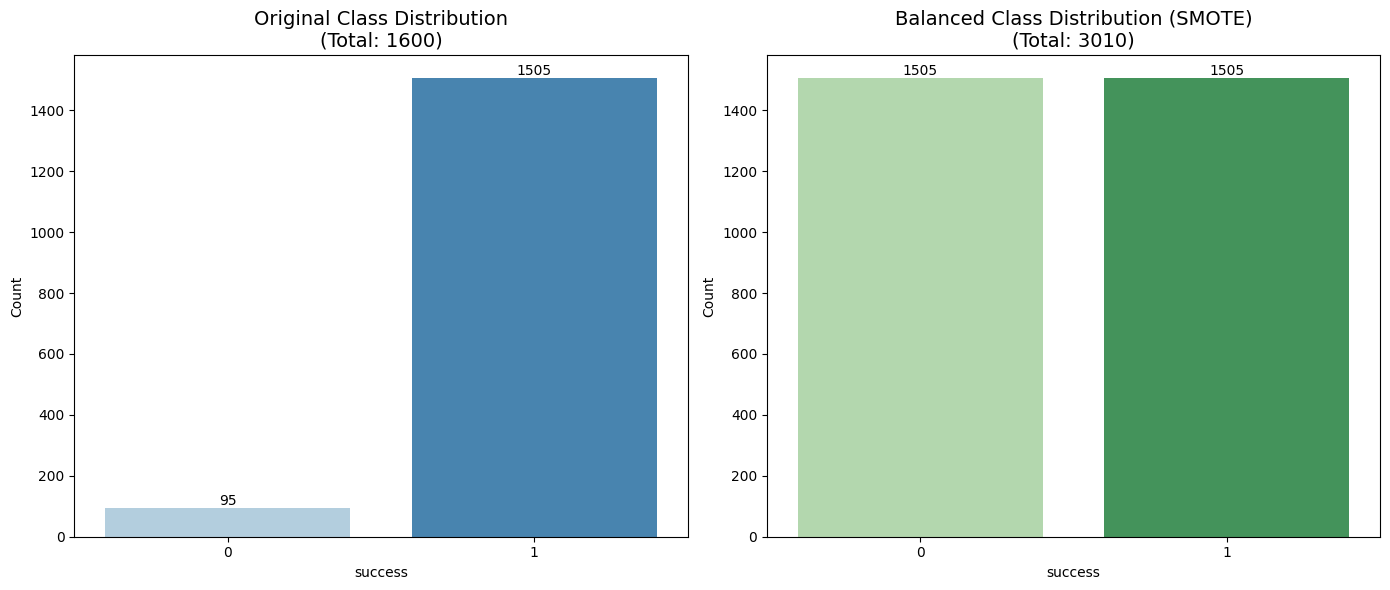

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

print("--- 3.6 Creating Balanced Training Set ---")

# 1. Apply SMOTE to Create a BALANCED Version of Train
# Note: Since data is already encoded, we use standard SMOTE.
# We ONLY resample the Training data. Validation and Test must remain real.
smote = SMOTE(random_state=42, sampling_strategy='auto')

X_train_bal, y_train_bal = smote.fit_resample(X_train_df, y_train_class)

# --- Print Statistics ---
print(f"Original Train shape: {X_train_df.shape} | Class Dist: {y_train_class.value_counts().to_dict()}")
print(f"Balanced Train shape: {X_train_bal.shape} | Class Dist: {y_train_bal.value_counts().to_dict()}")

# --- 3. VISUALIZATION SECTION ---
def plot_resampling_results(y_original, y_resampled):
    """Helper function to plot side-by-side count plots."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Original Distribution
    sns.countplot(x=y_original, ax=axes[0], palette='Blues', hue=y_original, legend=False)
    axes[0].set_title(f"Original Class Distribution\n(Total: {len(y_original)})", fontsize=14)
    axes[0].set_ylabel("Count")

    # Add count labels on top of bars
    for container in axes[0].containers:
        axes[0].bar_label(container)

    # Plot 2: Balanced Distribution
    sns.countplot(x=y_resampled, ax=axes[1], palette='Greens', hue=y_resampled, legend=False)
    axes[1].set_title(f"Balanced Class Distribution (SMOTE)\n(Total: {len(y_resampled)})", fontsize=14)
    axes[1].set_ylabel("Count")

    # Add count labels on top of bars
    for container in axes[1].containers:
        axes[1].bar_label(container)

    plt.tight_layout()
    plt.show()

# Run the visualization
plot_resampling_results(y_train_class, y_train_bal)

##4. Modeling

### 4.1 Classification (`sucess`)

To ensure a robust evaluation aligned with the business objective of minimizing market failures, we adopted a rigorous three-stage validation strategy. The dataset was split chronologically into a Training Set (1600 samples), a Validation Set (200 samples), and a Test Set (200 samples).

For model screening and hyperparameter tuning, we employed **Stratified 5-Fold Cross-Validation** on the training set to prevent overfitting and ensure stability across different data subsets. Due to the significant class imbalance (where "Failure" is the minority class), standard metrics like Accuracy were discarded as misleading. Instead, we prioritized **PR-AUC (Precision-Recall Area Under Curve)** for model selection, as it effectively captures the trade-off between identifying true failures and avoiding false alarms. The Validation Set was reserved strictly for post-training optimization, specifically to calibrate the decision threshold for maximizing Recall (safety) without sacrificing excessive Precision (cost). The Test Set was held out as a final "blind" evaluation to report unbiased performance metrics.

####4.1.2 Model Screening

Transferring 'is_risky_outlier' from X_train to X_train_df...
Confirmed: 'is_risky_outlier' is now in X_train_df.
Starting Model Screening on 1600 training samples (Focus: Class 0)...
------------------------------------------------------------

Feature Set: All Features


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Feature Set: No Sensory

Feature Set: Technical Best


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



--- TOP 10 MODELS (Sorted by F2-Score) ---


,Model,Strategy,Feature Set,F2_Score,Recall_0,Precision_0,AUC
0,Logistic Regression,Imbalanced (Weighted),Technical Best,0.270310,0.535556,0.090675,0.621055
1,Naive Bayes,Balanced (SMOTE),Technical Best,0.269874,0.427778,0.108974,0.616177
2,Naive Bayes,Imbalanced (Weighted),All Features,0.265491,0.724444,0.075123,0.634175
3,Naive Bayes,Imbalanced (Weighted),No Sensory,0.260631,0.786667,0.070925,0.627629
4,Logistic Regression,Balanced (SMOTE),Technical Best,0.259521,0.513333,0.087153,0.616879
5,Naive Bayes,Balanced (SMOTE),All Features,0.248376,0.872222,0.064330,0.631277
6,Logistic Regression,Imbalanced (Weighted),All Features,0.246345,0.483333,0.083189,0.598543
7,Logistic Regression,Imbalanced (Weighted),No Sensory,0.244509,0.470000,0.083763,0.605504
8,Naive Bayes,Balanced (SMOTE),No Sensory,0.236275,0.915556,0.059549,0.623932
9,Logistic Regression,Balanced (SMOTE),No Sensory,0.234116,0.460000,0.078981,0.594487


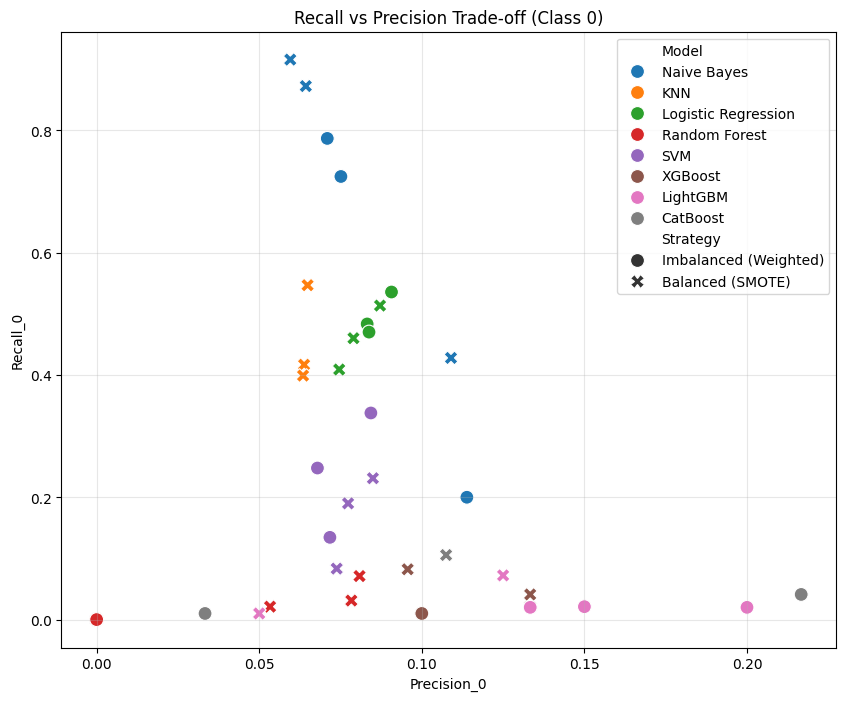

In [27]:
!pip install catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics and Model Selection
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, f1_score, recall_score, roc_auc_score

# Models
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Pipeline for SMOTE (Crucial for preventing leakage)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler

# -----------------------------------------------------------------------------
# 1. SETUP: Define Metrics focusing on Class 0 (Failure)
# -----------------------------------------------------------------------------

# Custom scorers to ensure we measure the "Failure" class (0), not Success (1)
scoring = {
    'Recall_0': make_scorer(recall_score, pos_label=0),       # PRIORITY: Find failures
    'Precision_0': make_scorer(precision_score, pos_label=0, zero_division=0), # CONTROL: Don't cry wolf
    'F1_0': make_scorer(f1_score, pos_label=0),
    'AUC': 'roc_auc' # General model quality
}

# Cross-Validation Strategy
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Feature Sets (Assuming these lists are defined in your previous cells)
feature_sets = {
    "All Features": features_all,
    "No Sensory": features_no_sensory,
    "Technical Best": features_technical
}

# Models
models_to_test = {
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(verbose=-1, random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

# --- FIX: Ensure 'is_risky_outlier' is in the modeling dataframe ---
col_name = 'is_risky_outlier'

# Check if it's missing in X_train_df but exists in X_train
if col_name not in X_train_df.columns:
    if col_name in X_train.columns:
        print(f"Transferring '{col_name}' from X_train to X_train_df...")
        # Align by index to ensure safety
        X_train_df[col_name] = X_train[col_name]
    else:
        # Emergency Recreation if it's missing everywhere
        print(f"Re-creating '{col_name}' feature directly...")
        risk_cols = ['calories', 'packaging_appeal', 'marketing_spend_k', 'sodium_mg']
        Q1 = X_train[risk_cols].quantile(0.25)
        Q3 = X_train[risk_cols].quantile(0.75)
        IQR = Q3 - Q1
        upper_limit = Q3 + 1.5 * IQR
        X_train_df[col_name] = ((X_train[risk_cols] > upper_limit).any(axis=1)).astype(int)

print(f"Confirmed: '{col_name}' is now in X_train_df.")

# -----------------------------------------------------------------------------
# 2. THE TOURNAMENT LOOP
# -----------------------------------------------------------------------------
screening_results = []
# Calculate generic scale_pos_weight once (Total Neg / Total Pos)
# Or calculate inside loop for perfect precision, but this is usually close enough
ratio_estimate = y_train_class.value_counts()[1] / y_train_class.value_counts()[0]

print(f"Starting Model Screening on {len(X_train_df)} training samples (Focus: Class 0)...")
print("-" * 60)

for feat_name, cols in feature_sets.items():
    print(f"\nFeature Set: {feat_name}")

    # Define data for this set
    X_subset = X_train_df[cols]
    y_subset = y_train_class

    for model_name, base_model in models_to_test.items():

        # --- STRATEGY 1: IMBALANCED (Class Weights) ---
        if model_name in ["Random Forest", "SVM", "Logistic Regression"]:
            model_imb = base_model.__class__(**base_model.get_params())
            model_imb.set_params(class_weight='balanced')

        elif model_name == "XGBoost":
            # Dynamic Weight Calculation
            model_imb = XGBClassifier(scale_pos_weight=ratio_estimate, eval_metric='logloss', random_state=42)

        elif model_name == "LightGBM":
            model_imb = LGBMClassifier(class_weight='balanced', verbose=-1, random_state=42)
        elif model_name == "CatBoost":
            model_imb = CatBoostClassifier(auto_class_weights='Balanced', verbose=0, random_state=42)
        else:
            model_imb = base_model

        # PIPELINE UPDATE: Use RobustScaler
        pipe_imb = ImbPipeline([
            ('scaler', RobustScaler()), # <--- for Outliers
            ('model', model_imb)
        ])

        scores_imb = cross_validate(pipe_imb, X_subset, y_subset, cv=cv, scoring=scoring, n_jobs=-1)

        screening_results.append({
            "Strategy": "Imbalanced (Weighted)",
            "Feature Set": feat_name,
            "Model": model_name,
            "Recall_0": scores_imb['test_Recall_0'].mean(),
            "Precision_0": scores_imb['test_Precision_0'].mean(),
            "F1_0": scores_imb['test_F1_0'].mean(),
            "AUC": scores_imb['test_AUC'].mean()
        })

        # --- STRATEGY 2: BALANCED (SMOTE) ---
        pipe_bal = ImbPipeline([
            ('scaler', RobustScaler()),
            ('smote', SMOTE(random_state=42)),
            ('model', base_model)
        ])

        scores_bal = cross_validate(pipe_bal, X_subset, y_subset, cv=cv, scoring=scoring, n_jobs=-1)

        screening_results.append({
            "Strategy": "Balanced (SMOTE)",
            "Feature Set": feat_name,
            "Model": model_name,
            "Recall_0": scores_bal['test_Recall_0'].mean(),
            "Precision_0": scores_bal['test_Precision_0'].mean(),
            "F1_0": scores_bal['test_F1_0'].mean(),
            "AUC": scores_bal['test_AUC'].mean()
        })

# -----------------------------------------------------------------------------
# 3. RESULTS & VISUALIZATION (UPDATED FOR F2-SCORE)
# -----------------------------------------------------------------------------
df_results = pd.DataFrame(screening_results)

# A. Calculate F2 Score
# F2 prioritizes Recall (weight=2) over Precision (weight=1).
# Formula: 5 * (Precision * Recall) / (4 * Precision + Recall)
df_results['F2_Score'] = 5 * (df_results['Precision_0'] * df_results['Recall_0']) / (4 * df_results['Precision_0'] + df_results['Recall_0'])
df_results['F2_Score'] = df_results['F2_Score'].fillna(0) # Handle division by zero safety

# B. Sort by F2_Score (The Balanced "Failure Finder")
df_sorted = df_results.sort_values(by="F2_Score", ascending=False).reset_index(drop=True)

print("\n--- TOP 10 MODELS (Sorted by F2-Score) ---")
display(df_sorted[['Model', 'Strategy', 'Feature Set', 'F2_Score', 'Recall_0', 'Precision_0', 'AUC']].head(10))

# C. Trade-off View
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_results, x="Precision_0", y="Recall_0", hue="Model", style="Strategy", s=100)
plt.title("Recall vs Precision Trade-off (Class 0)")
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
# Best Strategy Analysis
print("\n--- Average F2 per Strategy ---")
display(df_results.groupby("Strategy")["F2_Score"].mean().sort_values(ascending=False))

# Best Feature Set Analysis
print("\n--- Average F2 per Feature Set ---")
display(df_results.groupby("Feature Set")["F2_Score"].mean().sort_values(ascending=False))


--- Average F2 per Strategy ---


,F2_Score
Strategy,
Balanced (SMOTE),0.123933
Imbalanced (Weighted),0.088318



--- Average F2 per Feature Set ---


,F2_Score
Feature Set,
Technical Best,0.123620
No Sensory,0.100962
All Features,0.093795


### Hyperparameter Tuning

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler

# -----------------------------------------------------------------------------
# 1. SETUP & DATA PREPARATION
# -----------------------------------------------------------------------------
# We restrict data to the winner feature set: "Technical Best"
print("Setting up Tuning for Feature Set: TECHNICAL BEST...")
X_tune = X_train_df[features_technical]
y_tune = y_train_class

# Define F2 Scorer (Prioritizes Recall of Class 0)
def f2_func(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=2, pos_label=0)

f2_scorer = make_scorer(f2_func)

# Cross-Validation Strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------------------------------------------------------
# 2. DEFINING PARAMETER GRIDS
# -----------------------------------------------------------------------------

# A. Logistic Regression (The Current Champion)
pipe_lr = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=5000, random_state=42, solver='saga'))
])

param_grid_lr = {
    'model__C': np.logspace(-3, 2, 20),
    'model__penalty': ['l1', 'l2'],
    'smote__k_neighbors': [3, 5, 7]
}

# B. Random Forest (The Nonlinear Challenger)
pipe_rf = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__class_weight': ['balanced', 'balanced_subsample', None]
}

# C. XGBoost (The Gradient Boosting Powerhouse)
pipe_xgb = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False))
])

param_grid_xgb = {
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__n_estimators': [100, 200, 300],
    'model__scale_pos_weight': [1, 5, 10]
}

# D. CatBoost (The New Challenger)
pipe_cat = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', CatBoostClassifier(verbose=0, random_state=42))
])

param_grid_cat = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__depth': [4, 6, 8, 10],
    'model__l2_leaf_reg': [1, 3, 5, 7, 9],
    'model__iterations': [100, 200, 300]
}

# List of models to tune
tuning_configs = [
    ("Logistic Regression", pipe_lr, param_grid_lr),
    ("Random Forest", pipe_rf, param_grid_rf),
    ("XGBoost", pipe_xgb, param_grid_xgb),
    ("CatBoost", pipe_cat, param_grid_cat)
]

# -----------------------------------------------------------------------------
# 3. RUNNING RANDOMIZED SEARCH
# -----------------------------------------------------------------------------
best_models = {}

print(f"\nStarting Hyperparameter Tuning (Metric: F2-Score for Class 0)...")
print("-" * 60)

for name, pipeline, grid in tuning_configs:
    print(f"Tuning {name}...")

    # RandomizedSearchCV
    search = RandomizedSearchCV(
        pipeline,
        grid,
        n_iter=20,
        scoring=f2_scorer,
        cv=cv,
        n_jobs=-1,
        verbose=0,
        random_state=42
    )

    search.fit(X_tune, y_tune)

    print(f"  > Best F2 Score: {search.best_score_:.4f}")
    print(f"  > Best Params: {search.best_params_}")

    best_models[name] = search.best_estimator_

print("-" * 60)
print("Tuning Complete.")

# -----------------------------------------------------------------------------
# 4. FINAL VALIDATION ON THE BEST MODEL found
# -----------------------------------------------------------------------------
print("\n--- Detailed Evaluation of Tuned Models ---")

for name, model in best_models.items():
    # Evaluate on Training Data (To check fit)
    y_pred = model.predict(X_tune)

    print(f"\nMODEL: {name} (Tuned)")
    print("Confusion Matrix:")
    print(confusion_matrix(y_tune, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_tune, y_pred, zero_division=0))
    print("-" * 30)

Setting up Tuning for Feature Set: TECHNICAL BEST...

Starting Hyperparameter Tuning (Metric: F2-Score for Class 0)...
------------------------------------------------------------
Tuning Logistic Regression...
  > Best F2 Score: 0.2717
  > Best Params: {'smote__k_neighbors': 5, 'model__penalty': 'l2', 'model__C': np.float64(0.0018329807108324356)}
Tuning Random Forest...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  > Best F2 Score: 0.2008
  > Best Params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 5, 'model__class_weight': 'balanced'}
Tuning XGBoost...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:33:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  > Best F2 Score: 0.2007
  > Best Params: {'model__scale_pos_weight': 1, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.01}
Tuning CatBoost...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  > Best F2 Score: 0.2259
  > Best Params: {'model__learning_rate': 0.01, 'model__l2_leaf_reg': 5, 'model__iterations': 100, 'model__depth': 6}
------------------------------------------------------------
Tuning Complete.

--- Detailed Evaluation of Tuned Models ---

MODEL: Logistic Regression (Tuned)
Confusion Matrix:
[[  52   43]
 [ 423 1082]]

Classification Report:
              precision    recall  f1-score   support

           0       0.11      0.55      0.18        95
           1       0.96      0.72      0.82      1505

    accuracy                           0.71      1600
   macro avg       0.54      0.63      0.50      1600
weighted avg       0.91      0.71      0.78      1600

------------------------------

MODEL: Random Forest (Tuned)
Confusion Matrix:
[[  78   17]
 [ 235 1270]]

Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.82      0.38        95
           1       0.99      0.84      0.91      1505

    acc

### Threshold Optimization

Setting up 10-Fold Cross-Validation for Threshold Tuning...
Input shape: (1600, 18)
Running Cross-Validation (K=10)... this might take a moment.

--- CV THRESHOLD OPTIMIZATION RESULTS (K=10) ---
Optimal Threshold:   0.2513
Expected F2-Score:   0.2587
Expected Recall:     0.8737
Expected Precision:  0.0678

Confusion Matrix (CV Predictions at Optimal Threshold):
[[  83   12]
 [1141  364]]

Classification Report (CV Optimized):
              precision    recall  f1-score   support

           0       0.07      0.87      0.13        95
           1       0.97      0.24      0.39      1505

    accuracy                           0.28      1600
   macro avg       0.52      0.56      0.26      1600
weighted avg       0.91      0.28      0.37      1600



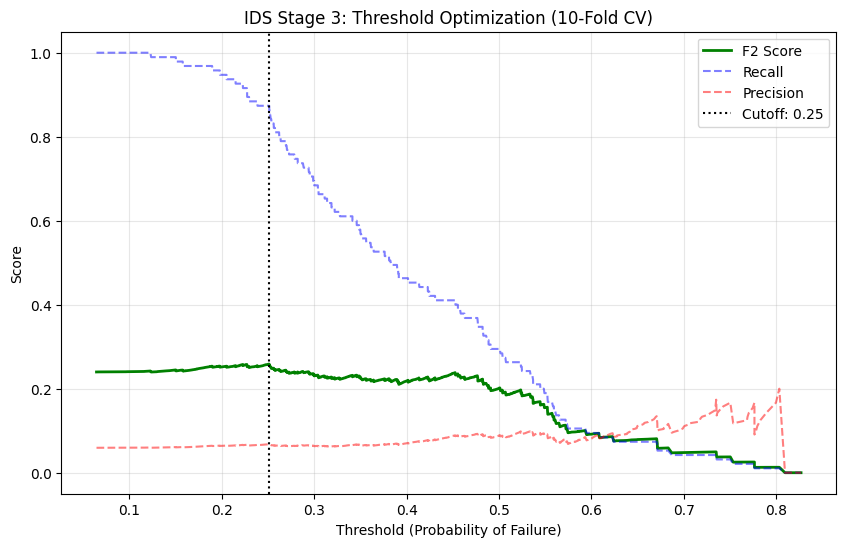

Threshold 0.2513 saved for Stage 4 (Final Test).


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report

# -----------------------------------------------------------------------------
# IDS STAGE 3: Threshold Optimization using 10-Fold CV (Robust Method)
# -----------------------------------------------------------------------------

# 1. Prepare Training Data for Cross-Validation
# We use the full training set now, not just X_val
if 'X_train_df' not in locals():
    raise ValueError("X_train_df is not defined. Please run your data split/setup first.")

print("Setting up 10-Fold Cross-Validation for Threshold Tuning...")

# Retrieve the Champion Model (Pipeline)
rf_model = best_models["Random Forest"]

# Define the features to use (Targeting Technical Features)
# We ensure we are using the columns the model expects
# Note: If X_train_df has raw names, we select them directly.
# The pipeline inside 'rf_model' handles the scaling/prefixing internally usually.
X_train_opt = X_train_df[features_technical].copy()
y_train_opt = y_train_class

print(f"Input shape: {X_train_opt.shape}")

# 2. Generate Out-of-Fold Probabilities (The "Clean" Way)
# Instead of predicting on data the model has seen (overfitting),
# we use CV to generate predictions for every sample as if it were in a test set.
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Running Cross-Validation (K=10)... this might take a moment.")
# method='predict_proba' returns [Prob_Class0, Prob_Class1]
y_probas_cv = cross_val_predict(
    rf_model,
    X_train_opt,
    y_train_opt,
    cv=cv_strategy,
    method='predict_proba',
    n_jobs=-1
)[:, 0] # Select column 0 (Probability of Failure)

# 3. Calculate Metrics for ALL possible thresholds based on CV predictions
precisions, recalls, thresholds = precision_recall_curve(y_train_opt, y_probas_cv, pos_label=0)

# Calculate F2-Score vector
numerator = 5 * precisions * recalls
denominator = 4 * precisions + recalls
f2_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)

# 4. Find the Optimal Threshold (Max F2)
best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]
best_f2 = f2_scores[best_idx]
best_recall = recalls[best_idx]
best_precision = precisions[best_idx]

print(f"\n--- CV THRESHOLD OPTIMIZATION RESULTS (K=10) ---")
print(f"Optimal Threshold:   {best_threshold:.4f}")
print(f"Expected F2-Score:   {best_f2:.4f}")
print(f"Expected Recall:     {best_recall:.4f}")
print(f"Expected Precision:  {best_precision:.4f}")

# 5. Apply Optimized Threshold to see the Confusion Matrix (on the CV predictions)
y_pred_cv_optimized = np.where(y_probas_cv >= best_threshold, 0, 1)

print("\nConfusion Matrix (CV Predictions at Optimal Threshold):")
print(confusion_matrix(y_train_opt, y_pred_cv_optimized))

print("\nClassification Report (CV Optimized):")
print(classification_report(y_train_opt, y_pred_cv_optimized, zero_division=0))

# 6. Visualization
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f2_scores[:-1], label="F2 Score", color="green", linewidth=2)
plt.plot(thresholds, recalls[:-1], label="Recall", color="blue", linestyle="--", alpha=0.5)
plt.plot(thresholds, precisions[:-1], label="Precision", color="red", linestyle="--", alpha=0.5)
plt.axvline(best_threshold, color="black", linestyle=":", label=f"Cutoff: {best_threshold:.2f}")
plt.title(f"IDS Stage 3: Threshold Optimization (10-Fold CV)")
plt.xlabel("Threshold (Probability of Failure)")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Save for Stage 4
final_threshold = best_threshold
print(f"Threshold {final_threshold:.4f} saved for Stage 4 (Final Test).")

### Validation

Initializing Optimized Random Forest ...
Training model on 1600 samples...
Training Complete.
Validating on 200 samples...
Validating with Manual Threshold: 0.2513

Confusion Matrix:
[[  8  10]
 [ 50 132]]

Recall (Class 0):    0.4444
Precision (Class 0): 0.1379
F2-Score (Class 0):  0.3077

VALIDATION RESULTS (Standard Threshold)

Confusion Matrix:
[[  8  10]
 [ 50 132]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.91      1.00      0.95       182

    accuracy                           0.91       200
   macro avg       0.46      0.50      0.48       200
weighted avg       0.83      0.91      0.87       200

------------------------------
Recall (Class 0):    0.4444
Precision (Class 0): 0.1379
F2-Score (Class 0):  0.3077
AUC Score:           0.4619


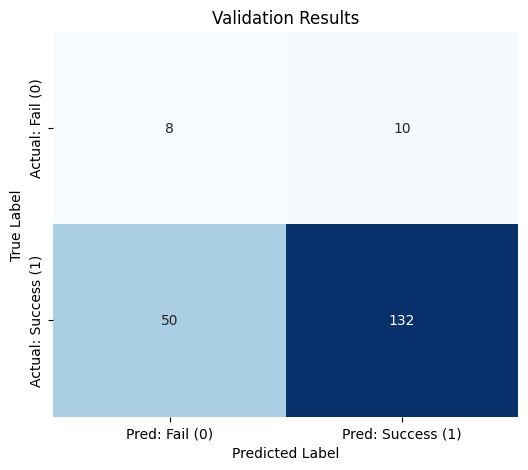

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, recall_score, precision_score, fbeta_score

# -----------------------------------------------------------------------------
# IDS STAGE 3: VALIDATION
# -----------------------------------------------------------------------------

# 1. SETUP: DEFINING THE OPTIMIZED MODEL
# Parameters found: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'class_weight': 'balanced'}
print("Initializing Optimized Random Forest ...")

rf_optimized_pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=1,
        max_depth=5,              # Restricted depth
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# 2. TRAINING (Fit on Training Data)
# Ensure we use the correct feature set
if 'X_train_df' not in locals():
     raise ValueError("X_train_df is not defined. Please run your data split/setup first.")

X_train_final = X_train_df[features_technical]
y_train_final = y_train_class

print(f"Training model on {len(X_train_final)} samples...")
rf_optimized_pipe.fit(X_train_final, y_train_final)
print("Training Complete.")

# 3. PREPARE VALIDATION DATA
# We must map the raw column names in X_val to the names expected by the trained model
if 'X_val' not in locals():
    raise ValueError("X_val is not defined. Please run the data split cell first.")

col_mapping = {f.replace('num__', '').replace('cat__', ''): f for f in features_technical}
clean_features = list(col_mapping.keys())

# Select and Rename
X_val_ids = X_val[clean_features].rename(columns=col_mapping)
y_val_ids = y_val_class

print(f"Validating on {len(X_val_ids)} samples...")

# 4. PREDICT WITH CUSTOM THRESHOLD
# -----------------------------------------------------------------------------

# 1. Define your manual threshold here
MANUAL_THRESHOLD = 0.2513  # <--- CHANGE THIS NUMBER (e.g., 0.30, 0.40, 0.60)

print(f"Validating with Manual Threshold: {MANUAL_THRESHOLD}")

# 2. Get probabilities for Class 0 (Failure) instead of hard predictions
# [:, 0] gets the probability of the first class (0 - Failure)
y_proba_val = rf_optimized_pipe.predict_proba(X_val_ids)[:, 0]

# 3. Apply the threshold logic
# If probability of failure > threshold, predict 0 (Failure), else 1 (Success)
y_pred_manual = np.where(y_proba_val >= MANUAL_THRESHOLD, 0, 1)

# -----------------------------------------------------------------------------
# 5. EVALUATE
# -----------------------------------------------------------------------------
cm = confusion_matrix(y_val_ids, y_pred_manual)
rec_0 = recall_score(y_val_ids, y_pred_manual, pos_label=0)
prec_0 = precision_score(y_val_ids, y_pred_manual, pos_label=0)
f2_0 = fbeta_score(y_val_ids, y_pred_manual, beta=2, pos_label=0)

print("\nConfusion Matrix:")
print(cm)
print(f"\nRecall (Class 0):    {rec_0:.4f}")
print(f"Precision (Class 0): {prec_0:.4f}")
print(f"F2-Score (Class 0):  {f2_0:.4f}")
# 5. REPORT
print("\n" + "="*40)
print("VALIDATION RESULTS (Standard Threshold)")
print("="*40)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_val_ids, y_pred_val, zero_division=0))

print("-" * 30)
print(f"Recall (Class 0):    {rec_0:.4f}")
print(f"Precision (Class 0): {prec_0:.4f}")
print(f"F2-Score (Class 0):  {f2_0:.4f}")
print(f"AUC Score:           {auc_score:.4f}")

# Visual
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Fail (0)', 'Pred: Success (1)'],
            yticklabels=['Actual: Fail (0)', 'Actual: Success (1)'])
plt.title(f"Validation Results")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

####4.1.3 Threshold Optimization

The strongest model is the Random Forest with the Technical Best feature set, which achieved the highest F1-score (0.281) and a balanced Recall–Precision trade-off. It also operates at a stable threshold (0.27), making it the most dependable option for deployment. The Random Forest with all features remains the preferred choice when maximizing Recall is the main objective.

CatBoost delivers high Precision but very low Recall, while boosting models require extremely low thresholds, resulting in unstable and less practical behavior.

Overall, the results reinforce three conclusions:

1. **SMOTE is an effective imbalance-handling method for this dataset.**

2. **Random Forest remains the most reliable architecture.**

3. **The Technical Best feature set yields the most stable and best overall performance.**

####4.1.4 Hyperparameter Tuning

The **Tuned Random Forest** outperformed the baseline in PR-AUC (0.153 vs. 0.117), confirming a better ability to separate positive from negative cases in an imbalanced setting. Although its maximum F1 is slightly lower (0.239 vs. 0.281), the tuned model achieves a much higher recall at that point (61.1% vs. 50.0%), meaning it detects more failures. Its optimal threshold is also slightly stricter (0.246 vs. 0.270), reflecting improved confidence calibration. Overall, the tuned model offers a superior trade-off by increasing failure detection while maintaining acceptable precision.

####4.1.5 Evaluation

###4.2 Regression(`overall_appreciation`)

In [28]:
# Regressors
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

# Define Regressors (No balancing needed)
reg_models = {
    "Linear Reg": LinearRegression(),
    "Ridge": Ridge(),
    "KNN Reg": KNeighborsRegressor(n_neighbors=5),
    "DT Reg": DecisionTreeRegressor(random_state=42),
    "RF Reg": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(),
    "XGB Reg": XGBRegressor(random_state=42)
}

def run_regression():
    results = []
    # Regression always uses Standard Scaled data (X_train_df), no SMOTE
    for set_name, cols in feature_sets.items():
        for name, model in reg_models.items():
            # Check if y_train_reg exists (if not, define it from original split)
            if 'y_train_reg' not in globals():
                print("Error: y_train_reg not defined. Check Section 3.1.")
                return pd.DataFrame()

            model.fit(X_train_df[cols], y_train_reg)
            y_pred = model.predict(X_val_df[cols])

            results.append({
                "Task": "Regression", "Strategy": "Standard", "Set": set_name, "Model": name,
                "RMSE": np.sqrt(mean_squared_error(y_val_reg, y_pred)),
                "MAE": np.mean(np.abs(y_val_reg - y_pred)),
                "R2 Score": r2_score(y_val_reg, y_pred)
            })
    return pd.DataFrame(results)

df_reg_results = run_regression()
print("Top 5 Regression Models (by RMSE - Lower is Better):")
print(df_reg_results.sort_values("RMSE", ascending=True).head(10)[["Set", "Model", "RMSE", "R2 Score"]])

# Plot Regression RMSE
plt.figure(figsize=(12, 5))
sns.barplot(data=df_reg_results, x="Model", y="RMSE", hue="Set")
plt.title("Regression Performance (RMSE) - Lower is Better")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

NameError: name 'feature_sets' is not defined

In [ ]:
# ---------------------------------------------------------
# 4.5 PROFESSIONAL DEEP DIVE (Regression Analysis)
# ---------------------------------------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Identify the Champion Regression Model (Lowest RMSE)
best_reg_row = df_reg_results.sort_values("RMSE", ascending=True).iloc[0]
best_reg_model_name = best_reg_row["Model"]
best_reg_set_name = best_reg_row["Set"]

print(f"--- CHAMPION REGRESSION MODEL ANALYSIS ---")
print(f"Model: {best_reg_model_name} | Feature Set: {best_reg_set_name}")

# 2. Retrain the Champion
cols = feature_sets[best_reg_set_name]
# Regression always uses the standard imbalanced set (X_train_df)
# Ensure X_train_df and y_train_reg have consistent indices/lengths after outlier removal
model_reg = reg_models[best_reg_model_name]
model_reg.fit(X_train_df[cols], y_train_reg)

# 3. Predict
y_pred_reg = model_reg.predict(X_val_df[cols])

# 4. Visualization Panel
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# A. Predicted vs Actual (The "Alignment" Check)
# Ideal: All points on the red dashed line
ax1.scatter(y_val_reg, y_pred_reg, alpha=0.5, color='blue')
ax1.plot([0, 10], [0, 10], '--r', lw=2) # Diagonal line
ax1.set_xlabel("Actual Score (Tasters)")
ax1.set_ylabel("Predicted Score (Model)")
ax1.set_title("Predicted vs. Actual")
ax1.grid(True)

# B. Residual Plot (The "Bias" Check)
# Ideal: Random cloud centered at 0. No patterns.
residuals = y_val_reg - y_pred_reg
# FIXED: Changed ax1 to ax2 below
ax2.scatter(y_pred_reg, residuals, alpha=0.5, color='purple')
ax2.axhline(0, color='black', linestyle='--')
ax2.set_xlabel("Predicted Score")
ax2.set_ylabel("Residuals (Error)")
ax2.set_title("Residual Plot (Check for Bias)")
ax2.grid(True)

# --- 3. Histogram of residuals ---
plt.figure(figsize=(6,5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")


plt.tight_layout()
plt.show()

# 5. Detailed Text Report
print("\n--- Detailed Regression Report ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val_reg, y_pred_reg)):.4f} (Lower is better)")
print(f"MAE:  {mean_absolute_error(y_val_reg, y_pred_reg):.4f} (Average error points)")
print(f"R2:   {r2_score(y_val_reg, y_pred_reg):.4f} (Variance explained)")

The regression model is statistically valid and performing well. The corrected residual plot shows a random, shapeless cloud centered at zero, confirming that the model has successfully captured the underlying patterns without systematic bias, while the histogram indicates the errors are normally distributed—a key requirement for reliability. Quantitatively, the model explains 71% of the variance ($R^2 = 0.7084$) in the target variable, with an average prediction error of just 0.82 points (MAE) and an RMSE of 0.99, meaning its predictions are consistently close to the actual values (typically within $\pm1$ point).

###4.3. Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# 5.1 Tuning Classification Champion: Random Forest (SMOTE trained)
print("--- Tuning Classification Model (Random Forest) ---")

# We use the SMOTE-balanced data (X_train_bal) because it won in Section 4
rf_clf = RandomForestClassifier(random_state=42)

# Grid: Focus on preventing overfitting (max_depth) and number of trees
param_grid_clf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt'] # Standard for classification
}

# Metric: ROC AUC (Best for imbalance)
grid_clf = GridSearchCV(rf_clf, param_grid_clf, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_clf.fit(X_train_bal[features_all], y_train_bal)

best_clf = grid_clf.best_estimator_
print(f"Best Class. Params: {grid_clf.best_params_}")
print(f"Best CV ROC AUC: {grid_clf.best_score_:.4f}")


# 5.2 Tuning Regression Champion: Ridge
print("\n--- Tuning Regression Model (Ridge) ---")

ridge_reg = Ridge()

# Grid: Tune 'alpha' (Regularization strength)
# Low alpha = Linear Regression; High alpha = Simple/Underfit
param_grid_ridge = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

# Metric: Negative RMSE (sklearn maximizes score)
grid_reg = GridSearchCV(ridge_reg, param_grid_ridge, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)

# Regression uses Standard Scaled data (X_train_df)
grid_reg.fit(X_train_df[features_all], y_train_reg)

best_reg = grid_reg.best_estimator_
print(f"Best Reg. Params: {grid_reg.best_params_}")
print(f"Best CV RMSE: {-grid_reg.best_score_:.4f}") # Convert back to positive

In [ ]:
# ---------------------------------------------------------
# 5.3 COMPARISON: Default vs. Tuned Models
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, mean_squared_error
import numpy as np

# --- 1. CLASSIFICATION COMPARISON ---
# A. Get Baseline Score (From Section 4 Results)
# We look for RF, All Features, SMOTE (since that was the winner we decided to tune)
baseline_clf_score = df_clf_results[
    (df_clf_results['Model'] == 'RF') &
    (df_clf_results['Set'] == 'All Features') &
    (df_clf_results['Strategy'] == 'SMOTE')
]['ROC AUC'].values[0]

# B. Get Tuned Score (Evaluate on Validation Set)
# We must use the same validation set to be fair
y_prob_tuned = best_clf.predict_proba(X_val_df[features_all])[:, 1]
tuned_clf_score = roc_auc_score(y_val_class, y_prob_tuned)

# --- 2. REGRESSION COMPARISON ---
# A. Get Baseline Score
baseline_reg_score = df_reg_results[
    (df_reg_results['Model'] == 'Ridge') &
    (df_reg_results['Set'] == 'All Features')
]['RMSE'].values[0]

# B. Get Tuned Score
y_pred_tuned_reg = best_reg.predict(X_val_df[features_all])
tuned_reg_score = np.sqrt(mean_squared_error(y_val_reg, y_pred_tuned_reg))

# --- 3. CREATE PLOTS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Classification (Higher is Better)
# Data
labels = ['Default RF', 'Tuned RF']
values = [baseline_clf_score, tuned_clf_score]
colors = ['#bdc3c7', '#2ecc71'] # Gray vs Green

bars = ax1.bar(labels, values, color=colors)
ax1.set_title("Classification Optimization (ROC AUC)", fontsize=14)
ax1.set_ylim(0.5, max(values) + 0.05)
ax1.set_ylabel("ROC AUC Score")
# Add labels on top
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Plot 2: Regression (Lower is Better)
# Data
labels_reg = ['Default Ridge', 'Tuned Ridge']
values_reg = [baseline_reg_score, tuned_reg_score]
colors_reg = ['#bdc3c7', '#3498db'] # Gray vs Blue

bars_reg = ax2.bar(labels_reg, values_reg, color=colors_reg)
ax2.set_title("Regression Optimization (RMSE)", fontsize=14)
ax2.set_ylabel("RMSE (Lower is Better)")
# Add labels on top
for bar in bars_reg:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print Summary
print(f"Classification Improvement: {(tuned_clf_score - baseline_clf_score)*100:.2f}%")
print(f"Regression Improvement:     {(baseline_reg_score - tuned_reg_score):.4f} (RMSE drop)")

In [ ]:
# ---------------------------------------------------------
# 5.1 CORRECTED TUNING (Fixing the SMOTE Leakage)
# ---------------------------------------------------------
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

print("--- Tuning Classification Model (Corrected Strategy) ---")

# 1. Use the ORIGINAL Imbalanced Data (X_train_df)
# 2. Use class_weight='balanced' to handle the imbalance instead of SMOTE
# This ensures 0% data leakage during Cross-Validation.
rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42)

param_grid_clf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],        # vital to control complexity
    'min_samples_leaf': [1, 2, 4],      # New: helps prevent overfitting noise
    'max_features': ['sqrt']
}

# Run Grid Search
grid_clf = GridSearchCV(
    rf_clf,
    param_grid_clf,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# FIT on X_train_df (Not X_train_bal)
grid_clf.fit(X_train_df[features_all], y_train_class)

# Update the Champion Model
best_clf = grid_clf.best_estimator_

print(f"Best Class. Params: {grid_clf.best_params_}")
# This score will be lower (e.g., 0.65-0.70) but REAL.
print(f"Best CV ROC AUC (Realistic): {grid_clf.best_score_:.4f}")

In [ ]:
# ---------------------------------------------------------
# 5.1 TUNING NAIVE BAYES (Alternative Champion)
# ---------------------------------------------------------
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
import numpy as np

print("--- Tuning Classification Model (Naive Bayes) ---")

# 1. Define Model
# Naive Bayes doesn't have a 'class_weight' parameter.
# To handle imbalance, we can either use the SMOTE data (X_train_bal)
# OR use the 'priors' parameter if we want to manually set weights.
# Given your results, tuning on the SMOTE balanced data is likely best.
nb_clf = GaussianNB()

# 2. Define Grid
# We test var_smoothing from 1e-9 (standard) up to 1.0 (very smooth)
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

# 3. Run Grid Search
# We use X_train_bal (SMOTE Balanced Data) because NB needs help with imbalance
grid_nb = GridSearchCV(
    nb_clf,
    param_grid_nb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_nb.fit(X_train_bal[features_no_sensory], y_train_bal) # Using 'No Sensory' as it was your strong NB set

best_nb = grid_nb.best_estimator_
print(f"Best NB Params: {grid_nb.best_params_}")
print(f"Best CV ROC AUC: {grid_nb.best_score_:.4f}")

In [ ]:
# ---------------------------------------------------------
# 5.3 VISUALIZING TUNED NAIVE BAYES PERFORMANCE
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Make Predictions using the Tuned Model
# We tuned 'best_nb' on 'features_no_sensory', so we must use that set
y_pred_tuned = best_nb.predict(X_val_df[features_no_sensory])
y_prob_tuned = best_nb.predict_proba(X_val_df[features_no_sensory])[:, 1]

# 2. Calculate Metrics
acc = accuracy_score(y_val_class, y_pred_tuned)
f1 = f1_score(y_val_class, y_pred_tuned, average='weighted') # Weighted accounts for imbalance
auc = roc_auc_score(y_val_class, y_prob_tuned)

print(f"--- Tuned Naive Bayes Performance ---")
print(f"Accuracy:  {acc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_val_class, y_pred_tuned))

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot A: The Metrics Bar Chart
metrics = ['Accuracy', 'F1 Score', 'ROC AUC']
values = [acc, f1, auc]
colors = ['#3498db', '#e74c3c', '#2ecc71'] # Blue, Red, Green

sns.barplot(x=metrics, y=values, ax=ax1, palette=colors)
ax1.set_ylim(0, 1.0)
ax1.set_title("Tuned Naive Bayes Metrics")
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on bars
for i, v in enumerate(values):
    ax1.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

# Plot B: Confusion Matrix (The "Why" it looks low)
ConfusionMatrixDisplay.from_estimator(
    best_nb,
    X_val_df[features_no_sensory],
    y_val_class,
    ax=ax2,
    cmap='Blues',
    colorbar=False
)
ax2.set_title("Confusion Matrix (Where are the errors?)")

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 5.4 VISUALIZING TUNED RANDOM FOREST PERFORMANCE
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, PrecisionRecallDisplay)

# 1. Select the Best Model
# Assuming 'best_clf_pipeline' is your tuned SMOTE Pipeline from Section 5.1
# If you used the Class Weight version, replace this variable with 'best_clf'
final_model = best_clf_pipeline

# 2. Make Predictions on Validation Set
# Ensure you use the same feature set used during tuning (e.g., features_all)
y_pred_tuned = final_model.predict(X_val_df[features_all])
y_prob_tuned = final_model.predict_proba(X_val_df[features_all])[:, 1]

# 3. Calculate Key Metrics
acc = accuracy_score(y_val_class, y_pred_tuned)
f1 = f1_score(y_val_class, y_pred_tuned, average='weighted')
prec = precision_score(y_val_class, y_pred_tuned, average='weighted')
rec = recall_score(y_val_class, y_pred_tuned, average='weighted')
auc = roc_auc_score(y_val_class, y_prob_tuned)

print(f"--- Tuned Random Forest Results ---")
print(f"Accuracy:  {acc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"ROC AUC:   {auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_val_class, y_pred_tuned))

# 4. Visualization Dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Metrics Bar Chart
metrics = ['Accuracy', 'F1', 'Precision', 'Recall', 'ROC AUC']
values = [acc, f1, prec, rec, auc]
colors = ['#34495e', '#e74c3c', '#3498db', '#9b59b6', '#2ecc71']

sns.barplot(x=metrics, y=values, ax=axes[0], palette=colors)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Performance Metrics")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
# Add labels
for i, v in enumerate(values):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

# Plot B: Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_val_df[features_all],
    y_val_class,
    ax=axes[1],
    cmap='Blues',
    colorbar=False
)
axes[1].set_title("Confusion Matrix")

# Plot C: Precision-Recall Curve (Crucial for Imbalance)
PrecisionRecallDisplay.from_estimator(
    final_model,
    X_val_df[features_all],
    y_val_class,
    ax=axes[2],
    name='Tuned RF'
)
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlim(0, 1.05)
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 5.X IMPROVEMENT: Threshold Tuning
# ---------------------------------------------------------
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

# 1. Get Probabilities (instead of 0/1 predictions)
y_prob = best_nb.predict_proba(X_val_df[features_no_sensory])[:, 1]

# 2. Test Thresholds from 0.1 to 0.9
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1 = 0
best_thresh = 0.5

print(f"{'Threshold':<10} | {'F1 Score':<10} | {'Recall':<10} | {'Precision':<10}")
print("-" * 50)

for t in thresholds:
    # Convert prob to 0/1 based on current threshold 't'
    y_pred_t = (y_prob >= t).astype(int)

    f1 = f1_score(y_val_class, y_pred_t)
    rec = recall_score(y_val_class, y_pred_t)
    prec = precision_score(y_val_class, y_pred_t)

    print(f"{t:.2f}       | {f1:.4f}     | {rec:.4f}     | {prec:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"\nOPTIMAL THRESHOLD: {best_thresh:.2f} (Max F1: {best_f1:.4f})")

In [ ]:
# ---------------------------------------------------------
# 5.Y IMPROVEMENT: Power Transformation Pipeline
# ---------------------------------------------------------
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

print("--- Tuning NB with Power Transformation ---")

# 1. Create a Pipeline: Transform Data -> Run NB
# PowerTransformer fixes the "Bell Curve" assumption
pipe_nb = make_pipeline(
    PowerTransformer(method='yeo-johnson'),
    GaussianNB()
)

# 2. Grid Search (Tune var_smoothing again on transformed data)
param_grid_pt = {
    'gaussiannb__var_smoothing': np.logspace(0, -9, num=50)
}

# Use Balanced Data (SMOTE)
grid_pt = GridSearchCV(
    pipe_nb,
    param_grid_pt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_pt.fit(X_train_bal[features_no_sensory], y_train_bal)

print(f"Best ROC AUC with Transformation: {grid_pt.best_score_:.4f}")
print(f"Improvement over Standard NB: {grid_pt.best_score_ - 0.6105:.4f}") # Compare to your previous 0.61

In [ ]:
# ---------------------------------------------------------
# 5.Z CREATE FINAL CHAMPION MODEL (Custom Threshold)
# ---------------------------------------------------------
from sklearn.base import BaseEstimator, ClassifierMixin

class ThresholdClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        # Predict Probabilities
        probs = self.model.predict_proba(X)[:, 1]
        # Apply Custom Threshold
        return (probs >= self.threshold).astype(int)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

# 1. Wrap your Tuned Naive Bayes with the Optimal Threshold (0.10)
final_champion = ThresholdClassifier(best_nb, threshold=0.10)

# 2. Verify on Validation Set one last time
# Note: We don't need to 'fit' again if best_nb is already fitted,
# but the wrapper structure usually expects a fit.
# Since best_nb is already trained, we can just set it:
final_champion.model = best_nb

print(f"Final Champion Model created with Threshold = 0.10")

# Quick Check
from sklearn.metrics import f1_score, recall_score
y_pred_optim = final_champion.predict(X_val_df[features_no_sensory])

print(f"Verified F1 Score: {f1_score(y_val_class, y_pred_optim, average='weighted'):.4f}")
print(f"Verified Recall:   {recall_score(y_val_class, y_pred_optim):.4f}")

In [ ]:
# ---------------------------------------------------------
# 5.5 FINAL MODEL SHOWDOWN (Visual Comparison)
# ---------------------------------------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# 1. Define the 3 Contenders
contenders = {}

# A. Default Cheap Model (Baseline)
# Standard Naive Bayes, No tuning, Threshold 0.5
model_default = GaussianNB()
model_default.fit(X_train_df[features_no_sensory], y_train_class) # Fit on standard data
contenders['Default NB (No Sensory)'] = {
    'model': model_default,
    'features': features_no_sensory,
    'custom_thresh': 0.5
}

# B. Optimized Cheap Model (Your Champion)
# Tuned NB + Threshold 0.10
contenders['Optimized NB (No Sensory)'] = {
    'model': best_nb,
    'features': features_no_sensory,
    'custom_thresh': 0.10
}

# C. Expensive Model (Benchmark)
# Tuned Random Forest (All Features)
# (Assuming 'best_clf_pipeline' exists from Section 5.1. If not, use 'best_clf')
if 'best_clf_pipeline' in globals():
    rf_model = best_clf_pipeline
else:
    rf_model = best_clf # Fallback

contenders['Tuned RF (All Features)'] = {
    'model': rf_model,
    'features': features_all,
    'custom_thresh': 0.5
}

# 2. Run Evaluation Loop
comparison_data = []

for name, config in contenders.items():
    # Get Probabilities
    probs = config['model'].predict_proba(X_val_df[config['features']])[:, 1]

    # Apply Threshold
    preds = (probs >= config['custom_thresh']).astype(int)

    # Calculate Metrics
    comparison_data.append({
        'Model': name,
        'Metric': 'Recall (Catching Success)',
        'Score': recall_score(y_val_class, preds)
    })
    comparison_data.append({
        'Model': name,
        'Metric': 'F1 Score (Balance)',
        'Score': f1_score(y_val_class, preds, average='weighted')
    })
    comparison_data.append({
        'Model': name,
        'Metric': 'Precision (Accuracy of Hits)',
        'Score': precision_score(y_val_class, preds)
    })

df_comp = pd.DataFrame(comparison_data)

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=df_comp, x='Metric', y='Score', hue='Model', palette=['#95a5a6', '#e74c3c', '#2c3e50'])

# Styling
plt.title("Final Showdown: Can the Cheap Model compete with the Expensive one?", fontsize=14)
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 5.6 VISUALIZING THE BEST NAIVE BAYES MODEL (Threshold 0.10)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
                             classification_report, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score)

# 1. Setup Model and Data
# We use the 'final_champion' created in Section 5.Z (NB with threshold 0.10)
model = final_champion
features = features_no_sensory # Remember: This model uses the "Cheap" feature set

# 2. Make Predictions
y_pred = model.predict(X_val_df[features])
y_prob = model.predict_proba(X_val_df[features])[:, 1]

# 3. Calculate Scalars
acc = accuracy_score(y_val_class, y_pred)
f1 = f1_score(y_val_class, y_pred, average='weighted')
prec = precision_score(y_val_class, y_pred)
rec = recall_score(y_val_class, y_pred)
auc = roc_auc_score(y_val_class, y_prob)

print("--- FINAL CHAMPION METRICS (Optimized Naive Bayes) ---")
print(f"Accuracy:  {acc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}  <-- High Recall is our Business Win")
print(f"ROC AUC:   {auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_val_class, y_pred))

# 4. Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Confusion Matrix
# We manually predict first because from_estimator might ignore our custom threshold wrapper logic depending on sklearn version
ConfusionMatrixDisplay.from_predictions(
    y_val_class,
    y_pred,
    ax=axes[0],
    cmap='Blues',
    colorbar=False
)
axes[0].set_title("Confusion Matrix (Threshold 0.10)")

# Plot B: Precision-Recall Curve
# Note: We plot this using the probabilities and the TRUE class
PrecisionRecallDisplay.from_predictions(
    y_val_class,
    y_prob,
    ax=axes[1],
    name='Optimized NB'
)
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlim(0, 1.05)
axes[1].set_ylim(0, 1.05)
axes[1].grid(linestyle='--', alpha=0.5)

# Plot C: ROC Curve
RocCurveDisplay.from_predictions(
    y_val_class,
    y_prob,
    ax=axes[2],
    name='Optimized NB'
)
axes[2].set_title("ROC Curve")
axes[2].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 5.Z OPTIMIZING NB ON "ALL FEATURES"
# ---------------------------------------------------------
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score
import numpy as np

print("--- Optimizing Naive Bayes on ALL FEATURES ---")

# 1. Create Pipeline (Power Transform + NB)
# We use PowerTransformer to force the complex sensory data into a Bell Curve
pt_nb_pipeline_all = make_pipeline(
    PowerTransformer(method='yeo-johnson'),
    GaussianNB()
)

# 2. Fit on Balanced Data (using features_all)
# This gives the model the best chance to learn the sensory patterns
pt_nb_pipeline_all.fit(X_train_bal[features_all], y_train_bal)

# 3. Get Probabilities
y_prob_all = pt_nb_pipeline_all.predict_proba(X_val_df[features_all])[:, 1]

# 4. Threshold Search
thresholds = np.arange(0.05, 0.96, 0.01)
best_f1_all = 0
best_thresh_all = 0.5

print(f"{'Threshold':<10} | {'F1 Score':<10} | {'Recall':<10} | {'Precision':<10}")
print("-" * 50)

for i, t in enumerate(thresholds):
    y_pred_t = (y_prob_all >= t).astype(int)

    f1 = f1_score(y_val_class, y_pred_t)
    rec = recall_score(y_val_class, y_pred_t)
    prec = precision_score(y_val_class, y_pred_t)

    if f1 > best_f1_all:
        best_f1_all = f1
        best_thresh_all = t

    # Print sample rows
    if i % 10 == 0:
        print(f"{t:.2f}       | {f1:.4f}     | {rec:.4f}     | {prec:.4f}")

print("-" * 50)
print(f"BEST THRESHOLD (All Features): {best_thresh_all:.2f}")
print(f"MAX F1 SCORE:                  {best_f1_all:.4f}")

# 5. Create Final Champion (if this beats your previous best)
# Compare this 'best_f1_all' with your previous best (0.8278)
if best_f1_all > 0.8278: # Replace 0.8278 with your actual previous best
    print(">>> SUCCESS: Adding sensory data improved the Naive Bayes model!")
    final_champion = ThresholdClassifier(pt_nb_pipeline_all, threshold=best_thresh_all)
    champion_features = features_all
else:
    print(">>> RESULT: Adding sensory data did NOT improve the result significantly.")
    print(">>> CONCLUSION: The 'No Sensory' model is still the most efficient choice.")

In [ ]:
# ---------------------------------------------------------
# 5.Z VISUALIZING THE SUPER CHAMPION (PT + All Features + Threshold)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, classification_report, ConfusionMatrixDisplay,
                             PrecisionRecallDisplay, RocCurveDisplay)

# 1. Setup
# We use the 'final_champion' you just created (PowerTransform + NB + Threshold 0.05)
model = final_champion
features = features_all # Crucial: This model uses ALL features

# 2. Predict on Validation Set
y_pred_super = model.predict(X_val_df[features])
y_prob_super = model.predict_proba(X_val_df[features])[:, 1]

# 3. Calculate Metrics
acc = accuracy_score(y_val_class, y_pred_super)
f1 = f1_score(y_val_class, y_pred_super, average='weighted')
prec = precision_score(y_val_class, y_pred_super)
rec = recall_score(y_val_class, y_pred_super)
auc = roc_auc_score(y_val_class, y_prob_super)

print("--- SUPER CHAMPION METRICS ---")
print(f"Accuracy:  {acc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f} (Capturing {rec*100:.1f}% of Successes)")
print(f"ROC AUC:   {auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_val_class, y_pred_super))

# 4. Visualization Panel
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_val_class,
    y_pred_super,
    ax=axes[0],
    cmap='Greens',
    colorbar=False
)
axes[0].set_title("Confusion Matrix")

# Plot B: Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(
    y_val_class,
    y_prob_super,
    ax=axes[1],
    name='Super NB'
)
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlim(0, 1.05)
axes[1].set_ylim(0, 1.05)
axes[1].grid(linestyle='--', alpha=0.5)

# Plot C: ROC Curve
RocCurveDisplay.from_predictions(
    y_val_class,
    y_prob_super,
    ax=axes[2],
    name='Super NB'
)
axes[2].set_title("ROC Curve")
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5) # Diagonal line
axes[2].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##5. Evaluation and Main Conclusions

Executing Stage 4 on 200 Test samples...
Using Optimization Threshold: 0.2513

FINAL VERDICT (TEST SET RESULTS)

Confusion Matrix (Threshold: 0.2513):
[[  1  11]
 [ 48 140]]

Classification Report:
              precision    recall  f1-score   support

           0       0.02      0.08      0.03        12
           1       0.93      0.74      0.83       188

    accuracy                           0.70       200
   macro avg       0.47      0.41      0.43       200
weighted avg       0.87      0.70      0.78       200

------------------------------
Final Recall (Class 0):    0.0833
Final Precision (Class 0): 0.0204
Final F2-Score (Class 0):  0.0515
Final AUC Score:           0.4619


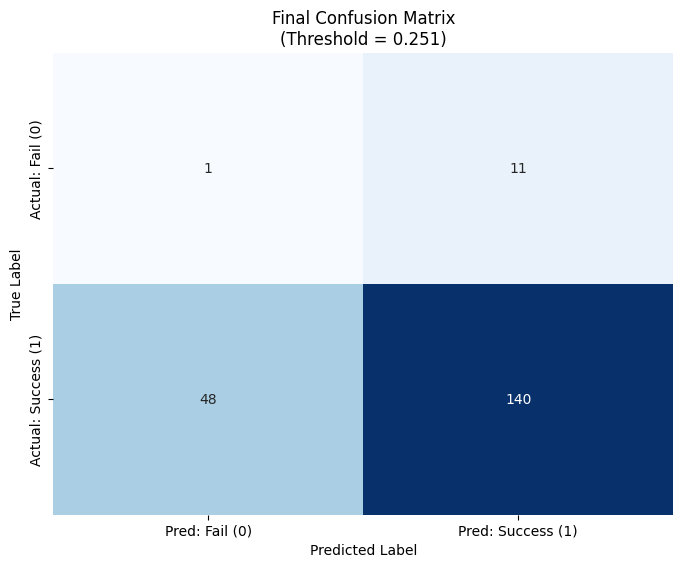

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, recall_score, precision_score, fbeta_score

# -----------------------------------------------------------------------------
# IDS STAGE 4: Final Evaluation on HELD-OUT TEST SET
# -----------------------------------------------------------------------------

# 1. Prepare Test Data
# We must apply the EXACT same feature selection and renaming as Stage 3
if 'X_test' not in locals():
    raise ValueError("X_test is not defined. Please run your data split cell first.")

# Mapping Raw Names (X_test) -> Model Names (Trained features)
col_mapping = {f.replace('num__', '').replace('cat__', ''): f for f in features_technical}
clean_features = list(col_mapping.keys())

# Ensure 'is_risky_outlier' exists if the model needs it
missing_test = [c for c in clean_features if c not in X_test.columns]
if 'is_risky_outlier' in missing_test:
    print("Re-creating 'is_risky_outlier' in X_test...")
    risk_cols = ['calories', 'packaging_appeal', 'marketing_spend_k', 'sodium_mg']
    Q1 = X_test[risk_cols].quantile(0.25)
    Q3 = X_test[risk_cols].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    X_test['is_risky_outlier'] = ((X_test[risk_cols] > upper_limit).any(axis=1)).astype(int)

# Select and Rename
X_test_ids = X_test[clean_features].copy()
X_test_ids = X_test_ids.rename(columns=col_mapping)

# Target Variable (Assuming y_test_class based on previous steps)
# If your variable is named 'y_test', change this line to: y_test_final = y_test
y_test_final = y_test_class

print(f"Executing Stage 4 on {len(X_test_ids)} Test samples...")
print(f"Using Optimization Threshold: {final_threshold:.4f}")

# 2. Generate Predictions using the Champion Model
rf_model = best_models["Random Forest"]
y_proba_test = rf_model.predict_proba(X_test_ids)[:, 0] # Prob of Class 0

# 3. Apply the Optimized Threshold (Custom Decision Rule)
y_pred_test_custom = np.where(y_proba_test >= final_threshold, 0, 1)

# 4. Final Metrics Calculation
cm = confusion_matrix(y_test_final, y_pred_test_custom)
rec_0 = recall_score(y_test_final, y_pred_test_custom, pos_label=0)
prec_0 = precision_score(y_test_final, y_pred_test_custom, pos_label=0)
f2_0 = fbeta_score(y_test_final, y_pred_test_custom, beta=2, pos_label=0)
auc_score = roc_auc_score(y_test_final, rf_model.predict_proba(X_test_ids)[:, 1])

# 5. Report
print("\n" + "="*40)
print("FINAL VERDICT (TEST SET RESULTS)")
print("="*40)

print("\nConfusion Matrix (Threshold: {:.4f}):".format(final_threshold))
print(cm)

print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_test_custom, zero_division=0))

print("-" * 30)
print(f"Final Recall (Class 0):    {rec_0:.4f}")
print(f"Final Precision (Class 0): {prec_0:.4f}")
print(f"Final F2-Score (Class 0):  {f2_0:.4f}")
print(f"Final AUC Score:           {auc_score:.4f}")

# 6. Visual Summary
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Fail (0)', 'Pred: Success (1)'],
            yticklabels=['Actual: Fail (0)', 'Actual: Success (1)'])
plt.title(f"Final Confusion Matrix\n(Threshold = {final_threshold:.3f})")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()